# Proyecto: Análisis exploratorio de datos para decisiones comerciales

### **Lección 1: ANÁLISIS EXPLORATORIO DE DATOS**

#### **Importación de librerias**

In [65]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#### **Creación de dataset**

In [66]:
np.random.seed(42)

#DataFrame cliente
n_clientes = 50
pesos_regiones = [0.05, 0.05, 0.05, 0.15, 0.2, 0.2, 0.05, 0.15, 0.05, 0.05]

clientes = pd.DataFrame({
   "id_cliente": [f"CLTE_{i}" for i in range(1, n_clientes + 1)],
   "nombre" : np.random.choice(["Emma", "Mateo", "Isabella", "Facundo", "Sofía", "Benjamín", "Emilia", "Gaspar",
           "Julieta", "Lucas", "Aurora", "Thiago", "Mía", "Liam", "Trinidad", "Santiago",
           "Josefa","Vicente", "Isidora","Noah","Ariel", "Alex", "Andrea"], n_clientes),
    "apellido": np.random.choice(["González", "Muñoz", "Rojas", "Díaz", "Pérez", "Soto", "Contreras", "Silva",
             "Martínez", "Sepúlveda", "Morales", "Rodríguez", "López", "Araya", "Fuentes",
             "Hernández", "Torres", "Espinoza", "Flores", "Castillo","Santibáñez","Arias",
             "Palacios"], n_clientes),
    "genero_cliente": np.random.choice(["F", "M", "Masculino","Femenino"], n_clientes),
    "edad_cliente": np.random.randint(18, 70, n_clientes),
    "correo_cliente":[f"cliente_{i}@gmail.com" for i in range(1, n_clientes + 1)],
    "region": np.random.choice(["Antofagasta", "Atacama", "Coquimbo", "Valparaíso", "Región Metropolitana","RM",
            "Maule", "Biobío", "La Araucanía", "Los Lagos"], n_clientes, p=np.array(pesos_regiones)/sum(pesos_regiones))
           })

#print(clientes.head())
#clientes.to_excel("vista_data_cliente.xlsx", index=False, sheet_name="Hoja1")

#DataFrame producto
n_productos = 20
productos = pd.DataFrame({
    "id_producto": np.arange(1000, 1000 + n_productos),
    "marca": np.random.choice(["Marca A", "Marca B", "Marca C", "Marca D"], n_productos),
    "precio_unitario": np.round(np.random.uniform(10_000, 1_000_000, n_productos), 0)
        })

#print(productos.head())
#productos.to_excel("vista_data_prod.xlsx", index=False, sheet_name="Hoja1")

productos_aux = pd.DataFrame([
    [1000,"Smartphone","Tecnología"],
    [1001,"Parlante","Tecnología"],
    [1002,"Audífonos","Tecnología"],
    [1003,"Notebook","Tecnología"],
    [1004,"Tablet","Tecnología"],
    [1005,"Smart TV","Tecnología"],
    [1006,"Smartwatch","Tecnología"],
    [1007,"Consola","Tecnología"],
    [1008,"Anillo inteligente","Tecnología"],
    [1009,"Lente inteligente","Tecnología"],
    [1010,"Aspiradora robot","ElectroHogar"],
    [1011,"Lavavajillas","ElectroHogar"],
    [1012,"Lavadora","ElectroHogar"],
    [1013,"Microondas","ElectroHogar"],
    [1014,"Lavadora-Secadora","ElectroHogar"],
    [1015,"Refrigerador","ElectroHogar"],
    [1016,"Freidora","ElectroHogar"],
    [1017,"Horno eléctico","ElectroHogar"],
    [1018,"Aire Acondicionado Portatil","ElectroHogar"],
    [1019,"Robot de Cocina","ElectroHogar"]  
    ], columns=["id_producto", "nombre_producto", "categoria_producto"])

#print(productos_aux.head())
#productos_aux.to_excel("vista_data_prod2.xlsx", index=False, sheet_name="Hoja1")

# Join left de DataFrames productos y productos_aux
df_productos= pd.merge(productos,productos_aux, on="id_producto", how="left")

#print(df_productos.head())
#df_productos.to_excel("vista_data_prod_F.xlsx", index=False, sheet_name="Hoja1")


#DataFrame transacciones
n_trans = 200

#Fecha de venta
fecha_inicio = np.datetime64('2025-01-01')
fecha_fin = np.datetime64('2025-12-31')
dias_totales = (fecha_fin - fecha_inicio).astype(int)
dias_aleatorios = np.random.randint(0, dias_totales, size=100)
fechas_aleatorias = fecha_inicio + dias_aleatorios.astype('timedelta64[D]')

transacciones = pd.DataFrame({
    "id_transaccion": np.arange(1, n_trans + 1),
    "fecha_venta": np.random.choice(fechas_aleatorias, n_trans),
    "id_cliente": np.random.choice(clientes["id_cliente"], n_trans),
    "id_producto": np.random.choice(productos["id_producto"], n_trans),
    "cantidad": np.random.randint(1, 6, n_trans),
    "descuento_aplicado": np.random.choice([0, 0.1, 0.20, 0.3], n_trans, p=[0.7, 0.1, 0.1, 0.1]),
    "visitas_previas": np.random.randint(1, 11, n_trans),
    "canales_venta": np.random.choice(["Página Web","Web", "App"], n_trans),
    "devolucion": np.random.choice([0, 1], n_trans, p=[0.9, 0.1]),
    "satisfaccion": np.random.randint(1, 3, n_trans)
    })

#Join left a los DataFrame de transacciones,clientes y df_productos
df_merged = transacciones.merge(clientes, on="id_cliente", how="left")
df_merged = df_merged.merge(df_productos, on="id_producto", how="left")

#df_merged.to_excel("vista_data_join.xlsx", index=False, sheet_name="Hoja1")

#Generar copia DataFrame df_merged
df_consolidado= df_merged.copy()

#print(df_consolidado["satisfaccion"].unique())

#Creación de columnas adicionales
df_consolidado["ingreso_venta"] = round(df_consolidado["cantidad"] * df_consolidado["precio_unitario"] * (1 - df_consolidado["descuento_aplicado"]))
df_consolidado["monto_devolucion"] = round(df_consolidado["devolucion"] * df_consolidado["ingreso_venta"] * np.random.uniform(0.3, 1.0, n_trans))
df_consolidado["satisfaccion"] = np.where(df_consolidado["devolucion"]==0, np.random.choice([3,4,5], n_trans, p=[0.15, 0.5, 0.35]), np.random.choice([1, 2], n_trans, p=[0.5, 0.5]))

#df_consolidado.to_excel("vista_data_penultimo.xlsx", index=False, sheet_name="Hoja1")

#Generar copia DataFrame df_consolidado
df_casos_NA= df_consolidado.copy()

# Agregar datos nulos
df_casos_NA.loc[np.random.choice(df_casos_NA.index, 10), "edad_cliente"] = np.nan
df_casos_NA.loc[np.random.choice(df_casos_NA.index, 20), "correo_cliente"] = np.nan

#Generar copia DataFrame df_casos_NA
df_casos_outliers= df_casos_NA.copy()

# Agregar datos outliers
df_casos_outliers.loc[np.random.choice(df_casos_outliers.index, 5), "precio_unitario"] = np.random.randint(2_000_000, 3_000_000)
df_casos_outliers["ingreso_venta"] = round(df_casos_outliers["cantidad"] * df_casos_outliers["precio_unitario"] *(1 - df_casos_outliers["descuento_aplicado"]))
df_casos_outliers["monto_devolucion"] = round(df_casos_outliers["devolucion"] * df_casos_outliers["ingreso_venta"] * np.random.uniform(0.3, 1.0, n_trans))


#Generar copia DataFrame df_casos_outliers
df_final= df_casos_outliers.copy()

#df_final.to_excel("Dataset_ComercioYA.xlsx", index=False, sheet_name="Hoja1")

df_final.to_csv("Dataset_ComercioYA.csv", index=False)

#### **Distinguir variables cuantitativas y categóricas**

In [67]:
# Vista de columnas
pd.set_option("display.max_columns", None)
df_final.info(verbose=True, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   id_transaccion      200 non-null    int64        
 1   fecha_venta         200 non-null    datetime64[s]
 2   id_cliente          200 non-null    str          
 3   id_producto         200 non-null    int64        
 4   cantidad            200 non-null    int32        
 5   descuento_aplicado  200 non-null    float64      
 6   visitas_previas     200 non-null    int32        
 7   canales_venta       200 non-null    str          
 8   devolucion          200 non-null    int64        
 9   satisfaccion        200 non-null    int64        
 10  nombre              200 non-null    str          
 11  apellido            200 non-null    str          
 12  genero_cliente      200 non-null    str          
 13  edad_cliente        190 non-null    float64      
 14  correo_cliente      1

Con el método *info* se puede observar que existen 10 variables categóricas y 12 variables cuantitativas.

Las variables categóricas son: id_cliente, canales_venta, nombre, apellido, genero_cliente, correo_cliente, region, marca, nombre_producto y categoria_producto.

Las variables cuantitativas son: id_transaccion, fecha_venta, id_producto, cantidad, descuento_aplicado, visitas_previas, devolucion, satisfaccion, edad_cliente, precio_unitario, ingreso_venta y monto_devolucion.



#### **Detectar valores faltantes o inconsistencias (IDA)**

##### 1) ¿Existen registros duplicados?

In [68]:
#Identificar duplicados
duplicados = df_final.duplicated()
print(f"\n\033[1mNúmero de duplicados identificados:\033[0m {duplicados.sum()}")


Número de duplicados identificados: 0


El DataFrame df_final no posee duplicados.

##### 2) ¿Existen valores faltantes?

In [69]:
nulos = df_final.isnull().sum()
print( f" \n\033[1m Columnas con valores faltantes \033[0m\n \n{nulos[ nulos > 0 ] }")

 
 Columnas con valores faltantes 
 
edad_cliente      10
correo_cliente    20
dtype: int64


Como existen valores faltantes en edad_cliente y correo_cliente se deben imputar los valores nulos. A continuación se procederá a darle una solución a estos casos.

* Caso edad_cliente

Como es una variable cuantitativa, los datos faltantes se pueden tratar con la imputación de la media o mediana según la distribución de los datos. Por este motivo, se va a utilizar IQR para detectar outliers, si hay outliers, se va a reemplazar los datos nulos con la mediana, de lo contrario, se va a utilizar la media.


In [70]:
#Identificación de outliers para edad_cliente:
    #Calcular cuartil 1 y 3
Q1 = df_final["edad_cliente"].quantile(0.25)   # Primer cuartil 25%
Q3 = df_final["edad_cliente"].quantile(0.75)   # Tercer cuartil 75%

#Rango intercuartiles (IQR)
IQR = Q3 - Q1

    #Límites superior e inferior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

    #DataFrame con las filas que están fuera de los límites
df_outliers = df_final[(df_final["edad_cliente"] < limite_inferior) | (df_final["edad_cliente"] > limite_superior)]

  #Imputación con media o mediana según existencia de outliers en edad_cliente
if len(df_outliers) == 0:
    df_final["edad_cliente"] = df_final["edad_cliente"].fillna(round(df_final["edad_cliente"].mean()))

else:
    df_final["edad_cliente"] = df_final["edad_cliente"].fillna(round(df_final["edad_cliente"].median()))

* Caso correo_cliente

Como es una variable categórica, se va a imputar con una categoría nueva a los datos nulos. Para ello, se reemplazará con "Sin correo electrónico".

In [71]:
#Imputación con una nueva categoría en correo_cliente
df_final["correo_cliente"]= df_final["correo_cliente"].fillna("Sin correo electrónico")

Se comprueba que ya no existen datos faltantes.

In [72]:
#Comprobación de existencia de valores nulos tras imputaciones
nulos2 = df_final.isnull().sum()
print( f" \n\033[1m Columnas con valores faltantes \033[0m\n \n{nulos2[ nulos2 > 0 ] }")

 
 Columnas con valores faltantes 
 
Series([], dtype: int64)


Por lo tanto, ya no hay datos faltantes.

##### 3) ¿Existen valores inconsistentes?

Para saber si existen valores inconsistentes se va a utilizar *unique* para obtener los valores únicos en las variables categóricas de canales_venta, genero_cliente, region, marca, nombre_producto y categoria_producto.

In [73]:
#Valores de canales_venta
print("\n\033[1m Valores de canales_venta\033[0m")
print(sorted(df_final["canales_venta"].unique()))

#Valores de genero_cliente
print("\n\033[1m Valores de genero_cliente\033[0m")
print(sorted(df_final["genero_cliente"].unique()))

#Valores de region
print("\n\033[1m Valores de region\033[0m")
print(sorted(df_final["region"].unique()))

#Valores de marca
print("\n\033[1m Valores de marca\033[0m")
print(sorted(df_final["marca"].unique()))

#Valores de nombre_producto
print("\n\033[1m Valores de nombre_producto\033[0m")
print(sorted(df_final["nombre_producto"].unique()))

#Valores de categoria_producto
print("\n\033[1m Valores de categoria_producto\033[0m")
print(sorted(df_final["categoria_producto"].unique()))


 Valores de canales_venta
['App', 'Página Web', 'Web']

 Valores de genero_cliente
['F', 'Femenino', 'M', 'Masculino']

 Valores de region
['Antofagasta', 'Atacama', 'Biobío', 'Coquimbo', 'La Araucanía', 'Los Lagos', 'Maule', 'RM', 'Región Metropolitana', 'Valparaíso']

 Valores de marca
['Marca A', 'Marca B', 'Marca C', 'Marca D']

 Valores de nombre_producto
['Aire Acondicionado Portatil', 'Anillo inteligente', 'Aspiradora robot', 'Audífonos', 'Consola', 'Freidora', 'Horno eléctico', 'Lavadora', 'Lavadora-Secadora', 'Lavavajillas', 'Lente inteligente', 'Microondas', 'Notebook', 'Parlante', 'Refrigerador', 'Robot de Cocina', 'Smart TV', 'Smartphone', 'Smartwatch', 'Tablet']

 Valores de categoria_producto
['ElectroHogar', 'Tecnología']


De lo anterior se puede observar que, canales_venta, genero_cliente y region presentan valores inconsistentes. En consecuencia, se toman las siguientes medidas:
- En region, se reemplaza “RM” por “Región Metropolitana”.
- En genero_cliente se reemplaza “Masculino” por “M” y “Femenino” por “F”.
- En canal_venta se reemplazó el dato de “Web” por “Página Web”.

In [74]:
#Remplazar valores: "RM" por "Región Metropolitana"
df_final["region"] = df_final["region"].str.replace(r"RM" , "Región Metropolitana",regex=True)

#Remplazar valores: "Masculino" por "M"
df_final["genero_cliente"] = df_final["genero_cliente"].str.replace(r"Masculino" , "M",regex=True)

#Remplazar valores: "Femenino" por "F"
df_final["genero_cliente"] = df_final["genero_cliente"].str.replace(r"Femenino" , "F",regex=True)

#Remplazar valores: "Web" por "Página Web"
df_final["canales_venta"] = df_final["canales_venta"].replace({"Web" : "Página Web"})

Extra: Creación de columnas para transformar de variables categóricas a cuantitativas

In [75]:
# Creación columna cuantitativa de genero_cliente donde F es 1 y M es 0
df_final["Ngenero_cliente"] = np.where(df_final["genero_cliente"]== "F", 1 , 0)

# Creación columna cuantitativa de canales_venta donde Página Web es 1 y App es 0
df_final["Ncanales_venta"]= np.where(df_final["canales_venta"]== "Página Web", 1 , 0)

# Creación columna cuantitativa de categoria_producto donde Tecnología es 1 y ElectroHogar es 0
df_final["Ncategoria_producto"]= np.where(df_final["categoria_producto"]== "Tecnología", 1 , 0)

# Creación columna cuantitativa de region
mapa_Nregiones = {"Antofagasta":2, "Atacama":3, "Coquimbo":4, "Valparaíso":5,
                   "Región Metropolitana":13, "Maule":6, "Biobío":8, "La Araucanía":9, "Los Lagos":10}

df_final["Nregion"] = df_final["region"].map(mapa_Nregiones)

# Creación columna cuantitativa de marca
mapa_Nmarca = {"Marca A": 1, "Marca B": 2, "Marca C": 3, "Marca D": 4}

df_final["Nmarca"] = df_final["marca"].map(mapa_Nmarca)
 
# Creación columna mes( cuantitativo) de fecha_venta 
df_final["Nmes"] = df_final["fecha_venta"].dt.month


Con el término de la Lección 1, los principales hallazgos fueron la identificación de las variables de la base y la existencia de valores faltantes e inconsistencias en el dataset, los cuales fueron corregidos dando paso a un dataframe listo para el análisis exploratorio de datos (EDA).

In [76]:
#Generar copia para EDA
df_EDA = df_final.copy()

#df_EDA.to_excel("vista_data_limpio.xlsx", index=False, sheet_name="Hoja1")

### **Lección 2: CONCEPTOS BÁSICOS DE ESTADÍSTICA DESCRIPTIVA**

#### **Calcular media, mediana, moda, varianza, desviación estándar**

##### Media

In [77]:
medias = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].mean()

print("\033[1m Media de variables \033[0m")
for col, val in medias.items():
    print(f"{col}: {val:,.2f}")

 Media de variables 
cantidad: 2.95
descuento_aplicado: 0.07
visitas_previas: 5.44
devolucion: 0.09
satisfaccion: 3.99
edad_cliente: 46.27
precio_unitario: 700,464.13
ingreso_venta: 1,951,008.01
monto_devolucion: 121,322.58


##### Mediana

In [78]:
mediana = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].median()

print(f"\033[1m Mediana de variables \033[0m")
for col, val in mediana.items():
    print(f"{col}: {val:,.2f}")

 Mediana de variables 
cantidad: 3.00
descuento_aplicado: 0.00
visitas_previas: 5.00
devolucion: 0.00
satisfaccion: 4.00
edad_cliente: 47.00
precio_unitario: 703,354.00
ingreso_venta: 1,520,495.50
monto_devolucion: 0.00


##### Moda

In [79]:
modas = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].mode()

modas_2 = modas.map(lambda x: f"{x:,.0f}")

print(f"\033[1m Moda de variables \033[0m \n {modas_2}")


 Moda de variables  
   cantidad descuento_aplicado visitas_previas devolucion satisfaccion  \
0        1                  0               2          0            4   
1      nan                nan               8        nan          nan   

  edad_cliente precio_unitario ingreso_venta monto_devolucion  
0           45         940,732       857,761                0  
1           49             nan     4,703,660              nan  


##### Varianza

In [80]:
varianza = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].var()

print(f"\033[1m Varianza de variables \033[0m")
for col, val in varianza.items():
    print(f"{col}: {val:,.2f}")

 Varianza de variables 
cantidad: 2.11
descuento_aplicado: 0.01
visitas_previas: 8.67
devolucion: 0.08
satisfaccion: 1.03
edad_cliente: 217.39
precio_unitario: 187,557,110,867.15
ingreso_venta: 2,676,616,174,959.96
monto_devolucion: 270,468,739,556.28


##### Desviación estándar

In [81]:
desviacion = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].std()

print(f"\033[1m Desviación estándar de variables \033[0m")
for col, val in desviacion.items():
    print(f"{col}: {val:,.2f}")

 Desviación estándar de variables 
cantidad: 1.45
descuento_aplicado: 0.10
visitas_previas: 2.94
devolucion: 0.29
satisfaccion: 1.01
edad_cliente: 14.74
precio_unitario: 433,078.64
ingreso_venta: 1,636,036.73
monto_devolucion: 520,066.09


#### **Determinar cuartiles y percentiles**

##### Cuartiles

In [82]:
cuartiles = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].quantile([0.25, 0.5, 0.75])

cuartiles_2 = cuartiles.map(lambda x: f"{x:,.2f}")


print(cuartiles_2)

     cantidad descuento_aplicado visitas_previas devolucion satisfaccion  \
0.25     2.00               0.00            3.00       0.00         4.00   
0.50     3.00               0.00            5.00       0.00         4.00   
0.75     4.00               0.10            8.00       0.00         5.00   

     edad_cliente precio_unitario ingreso_venta monto_devolucion  
0.25        35.75      410,463.00    787,487.00             0.00  
0.50        47.00      703,354.00  1,520,495.50             0.00  
0.75        58.00      883,810.00  2,822,196.00             0.00  


##### Percentiles

In [83]:
percentiles = df_EDA[["cantidad", "descuento_aplicado","visitas_previas","devolucion","satisfaccion",
                "edad_cliente","precio_unitario","ingreso_venta","monto_devolucion"]].quantile([0.01, 0.05, 0.15, 0.35, 0.55, 0.75, 0.95, 0.99])

percentiles_2 = percentiles.map(lambda x: f"{x:,.2f}")

print(percentiles_2)

     cantidad descuento_aplicado visitas_previas devolucion satisfaccion  \
0.01     1.00               0.00            1.00       0.00         1.00   
0.05     1.00               0.00            1.00       0.00         2.00   
0.15     1.00               0.00            2.00       0.00         3.00   
0.35     2.00               0.00            4.00       0.00         4.00   
0.55     3.00               0.00            6.00       0.00         4.00   
0.75     4.00               0.10            8.00       0.00         5.00   
0.95     5.00               0.30           10.00       1.00         5.00   
0.99     5.00               0.30           10.00       1.00         5.00   

     edad_cliente precio_unitario ingreso_venta monto_devolucion  
0.01        18.00      196,820.00    196,820.00             0.00  
0.05        21.00      196,820.00    327,697.10             0.00  
0.15        25.00      291,082.00    584,472.60             0.00  
0.35        45.00      490,758.00    883,415.90

#### **Generar histogramas y boxplots**

##### Histogramas

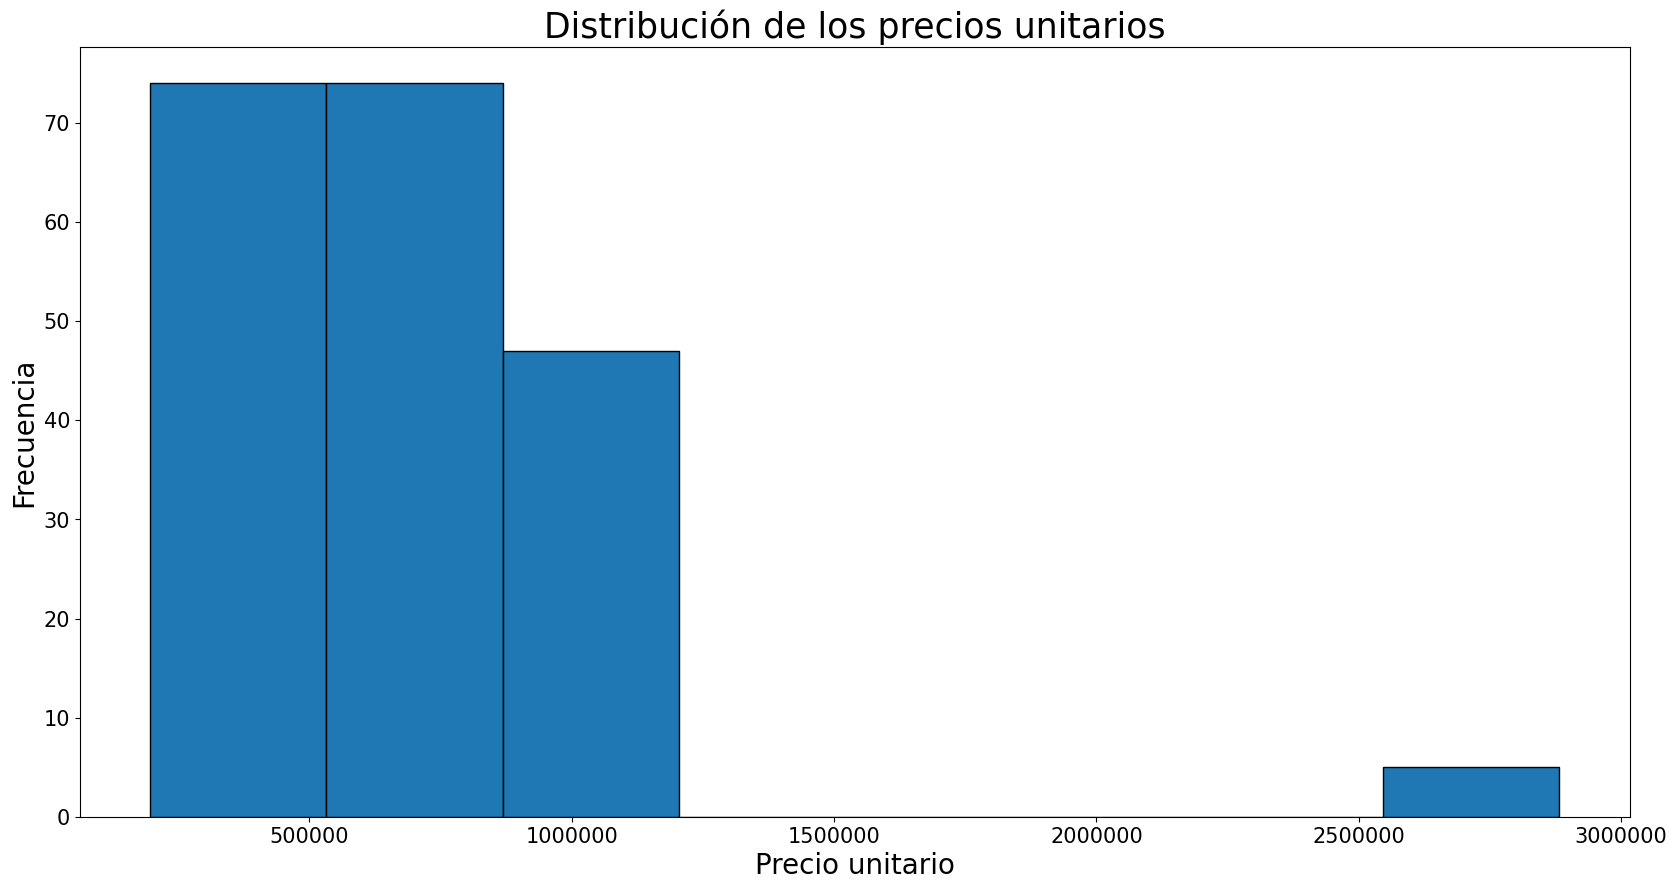

In [84]:
plt.figure( figsize=(20, 10) )
plt.hist( df_EDA["precio_unitario"], bins=8, edgecolor="black" )
plt.ticklabel_format(style="plain", axis="x")
plt.title("Distribución de los precios unitarios", fontsize=25)
plt.xlabel("Precio unitario", fontsize=20)
plt.ylabel("Frecuencia", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoHistograma1.png", dpi=300, bbox_inches='tight')
plt.show()

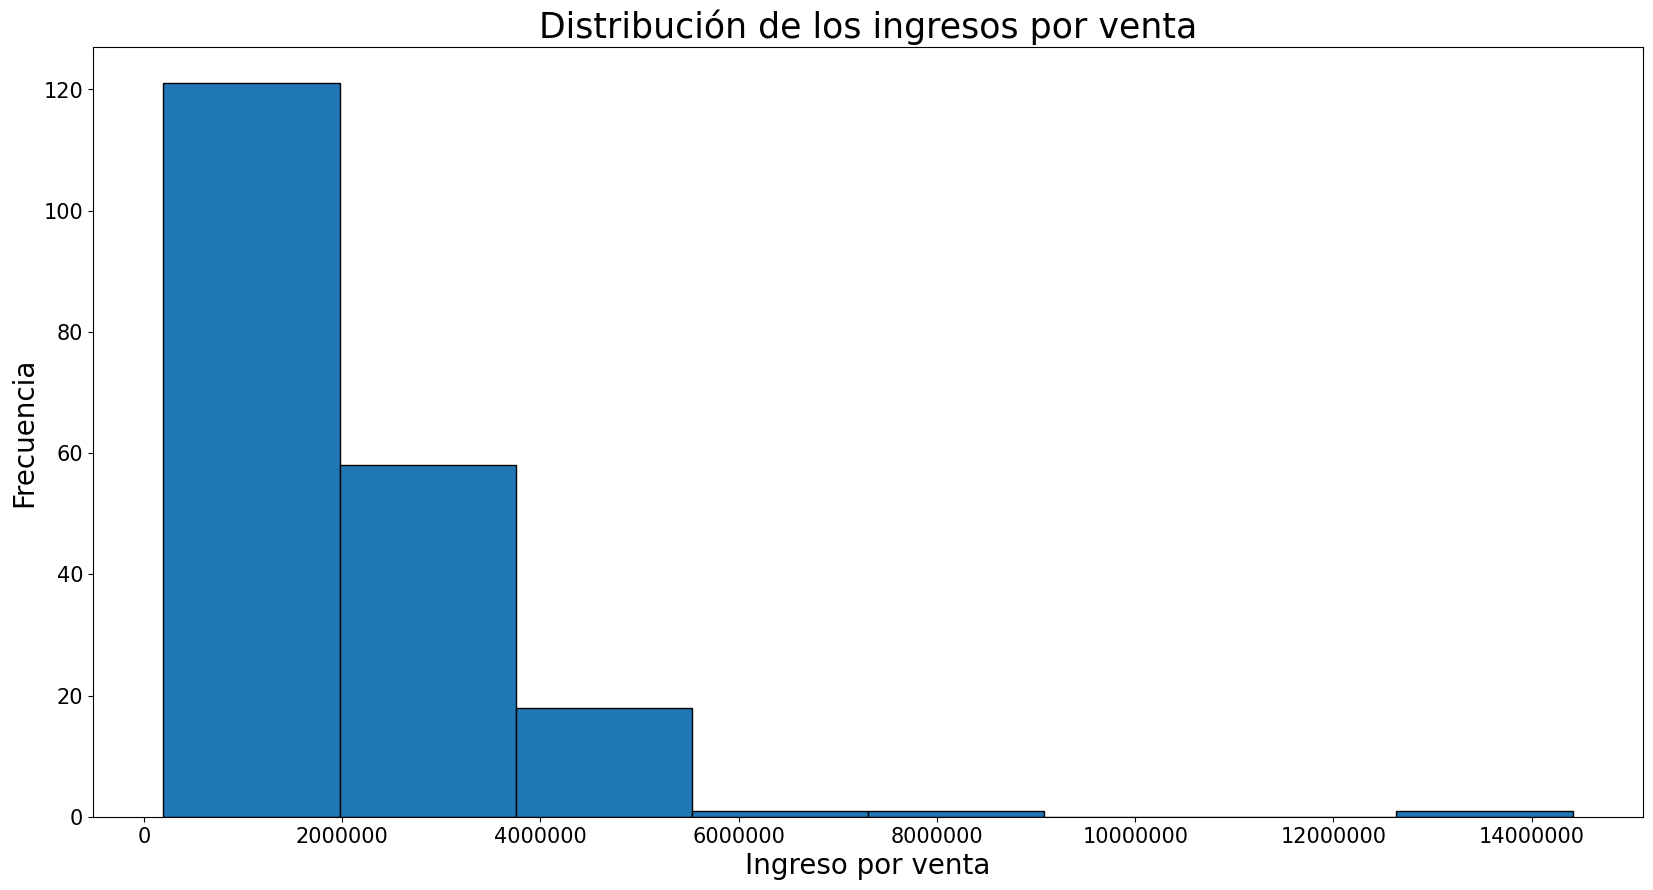

In [85]:
plt.figure( figsize=(20, 10) )
plt.hist( df_EDA["ingreso_venta"], bins=8, edgecolor="black" )
plt.ticklabel_format(style="plain", axis="x")
plt.title("Distribución de los ingresos por venta", fontsize=25)
plt.xlabel("Ingreso por venta", fontsize=20)
plt.ylabel("Frecuencia", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoHistograma2.png", dpi=300, bbox_inches='tight')
plt.show()

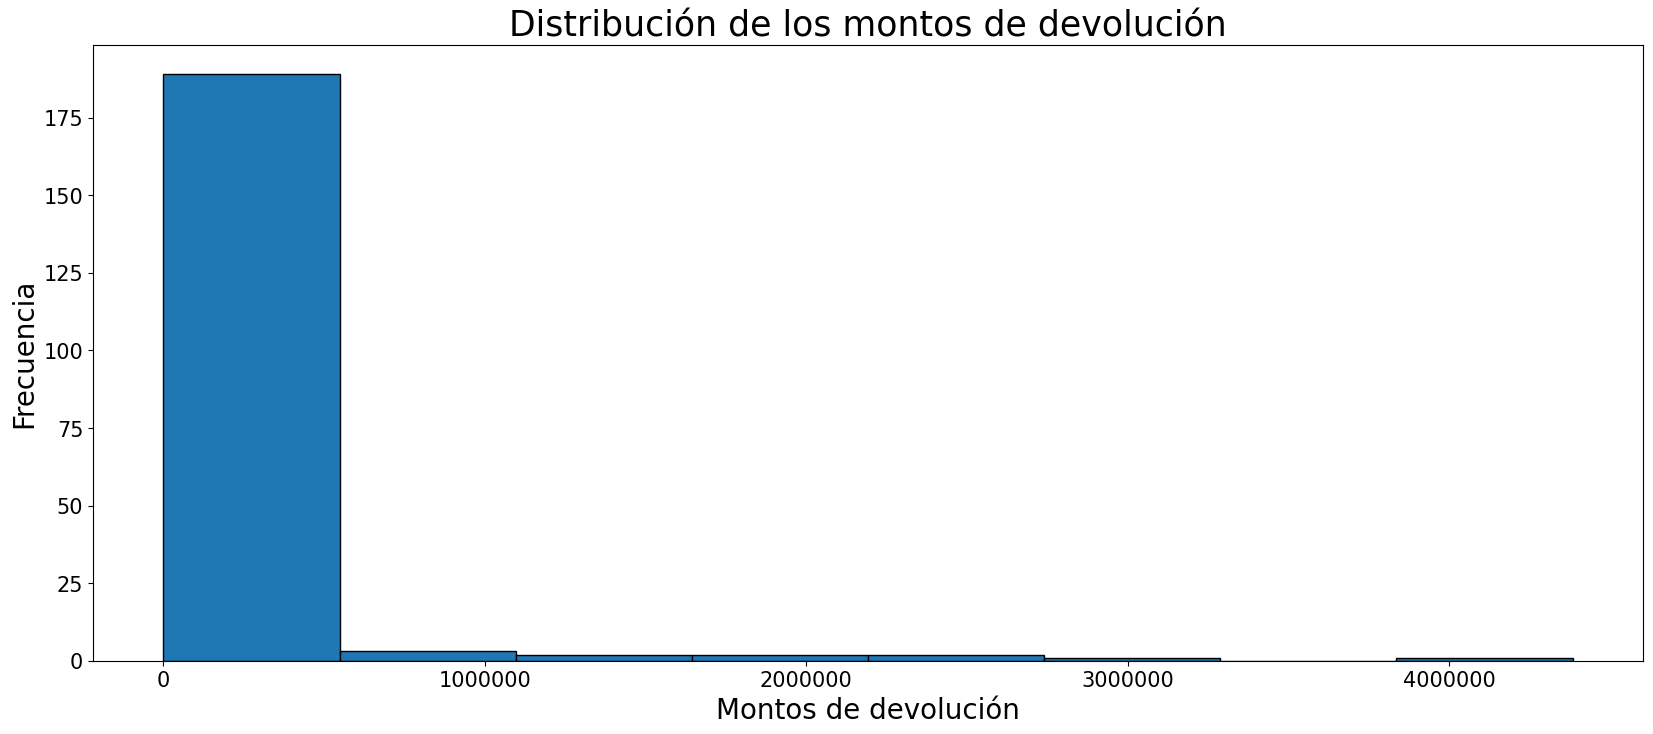

In [86]:
plt.figure( figsize=(20, 8) )
plt.hist( df_EDA["monto_devolucion"], bins=8, edgecolor="black" )
plt.ticklabel_format(style="plain", axis="x")
plt.title("Distribución de los montos de devolución", fontsize=25)
plt.xlabel("Montos de devolución", fontsize=20)
plt.ylabel("Frecuencia", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoHistograma3.png", dpi=300, bbox_inches='tight')
plt.show()

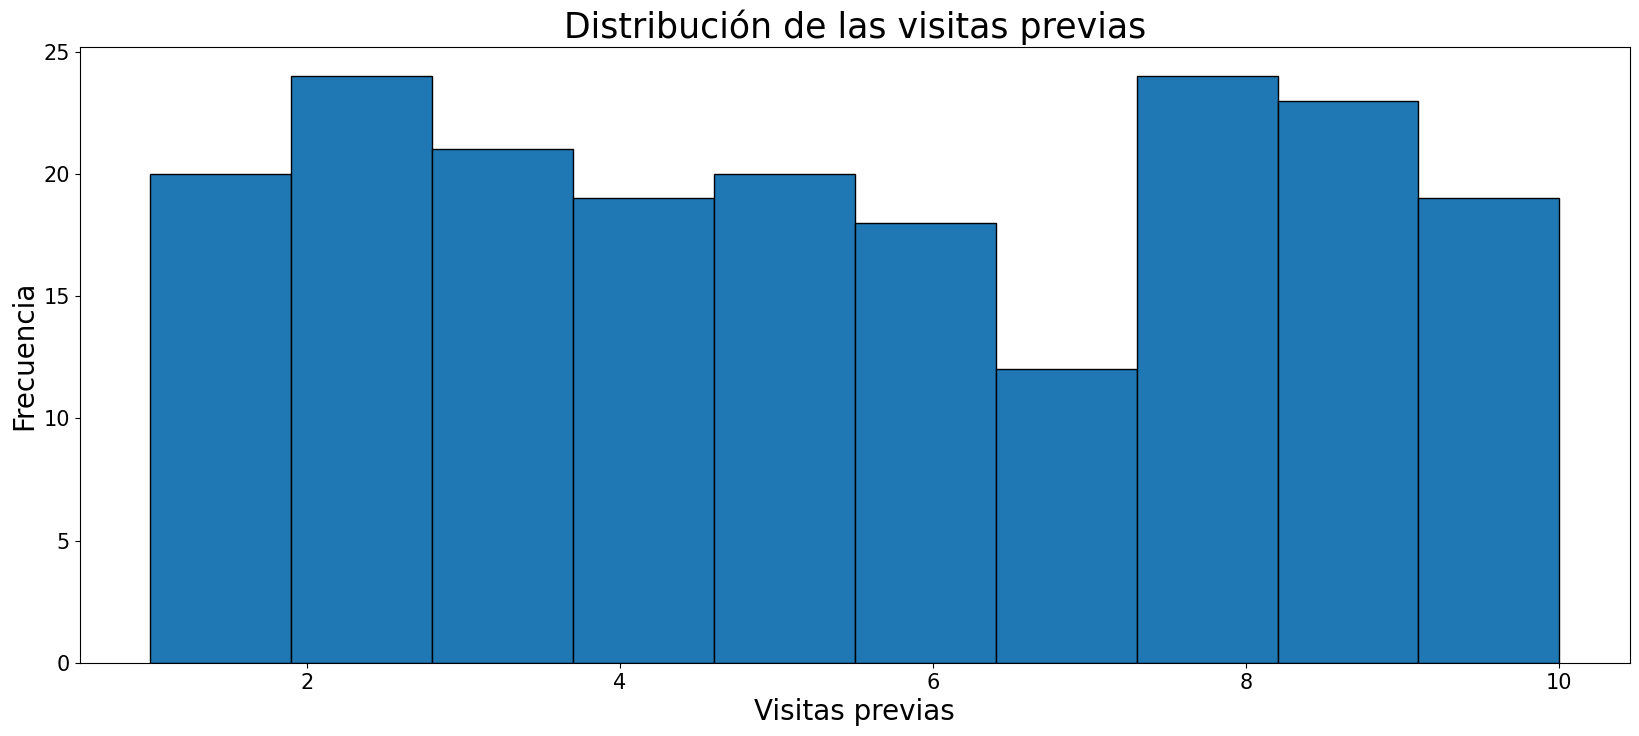

In [87]:
plt.figure( figsize=(20, 8) )
plt.hist( df_EDA["visitas_previas"], bins=10, edgecolor="black" )
plt.title("Distribución de las visitas previas", fontsize=25)
plt.xlabel("Visitas previas", fontsize=20)
plt.ylabel("Frecuencia", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoHistograma4.png", dpi=300, bbox_inches='tight')
plt.show()

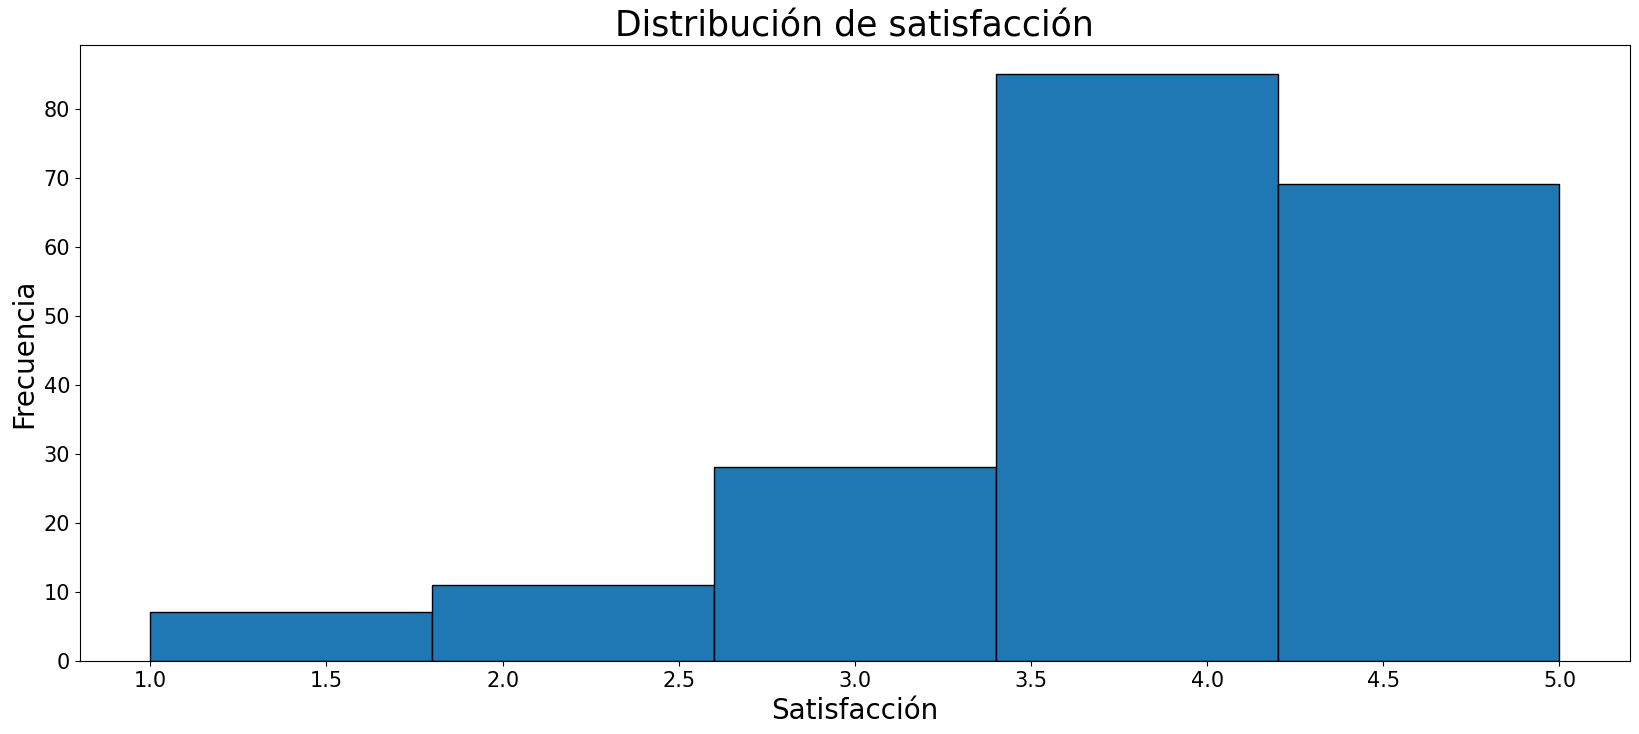

In [88]:
plt.figure( figsize=(20, 8) )
plt.hist( df_EDA["satisfaccion"], bins=5, edgecolor="black" )
plt.title("Distribución de satisfacción", fontsize=25)
plt.xlabel("Satisfacción", fontsize=20)
plt.ylabel("Frecuencia", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoHistograma5.png", dpi=300, bbox_inches='tight')
plt.show()

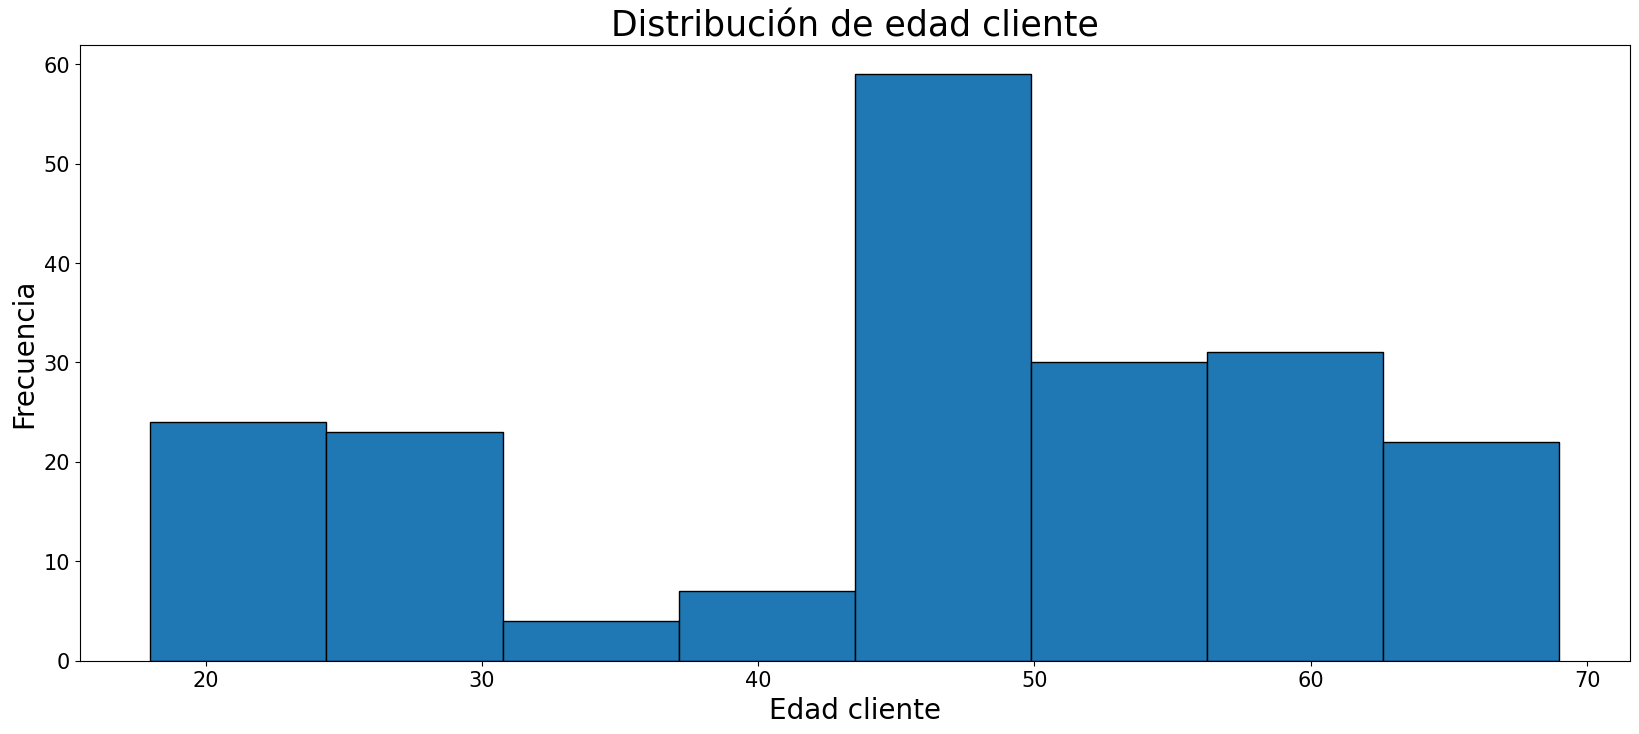

In [89]:
plt.figure( figsize=(20, 8) )
plt.hist( df_EDA["edad_cliente"], bins=8, edgecolor="black" )
plt.title("Distribución de edad cliente", fontsize=25)
plt.xlabel("Edad cliente", fontsize=20)
plt.ylabel("Frecuencia", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoHistograma6.png", dpi=300, bbox_inches='tight')
plt.show()

##### Boxplot

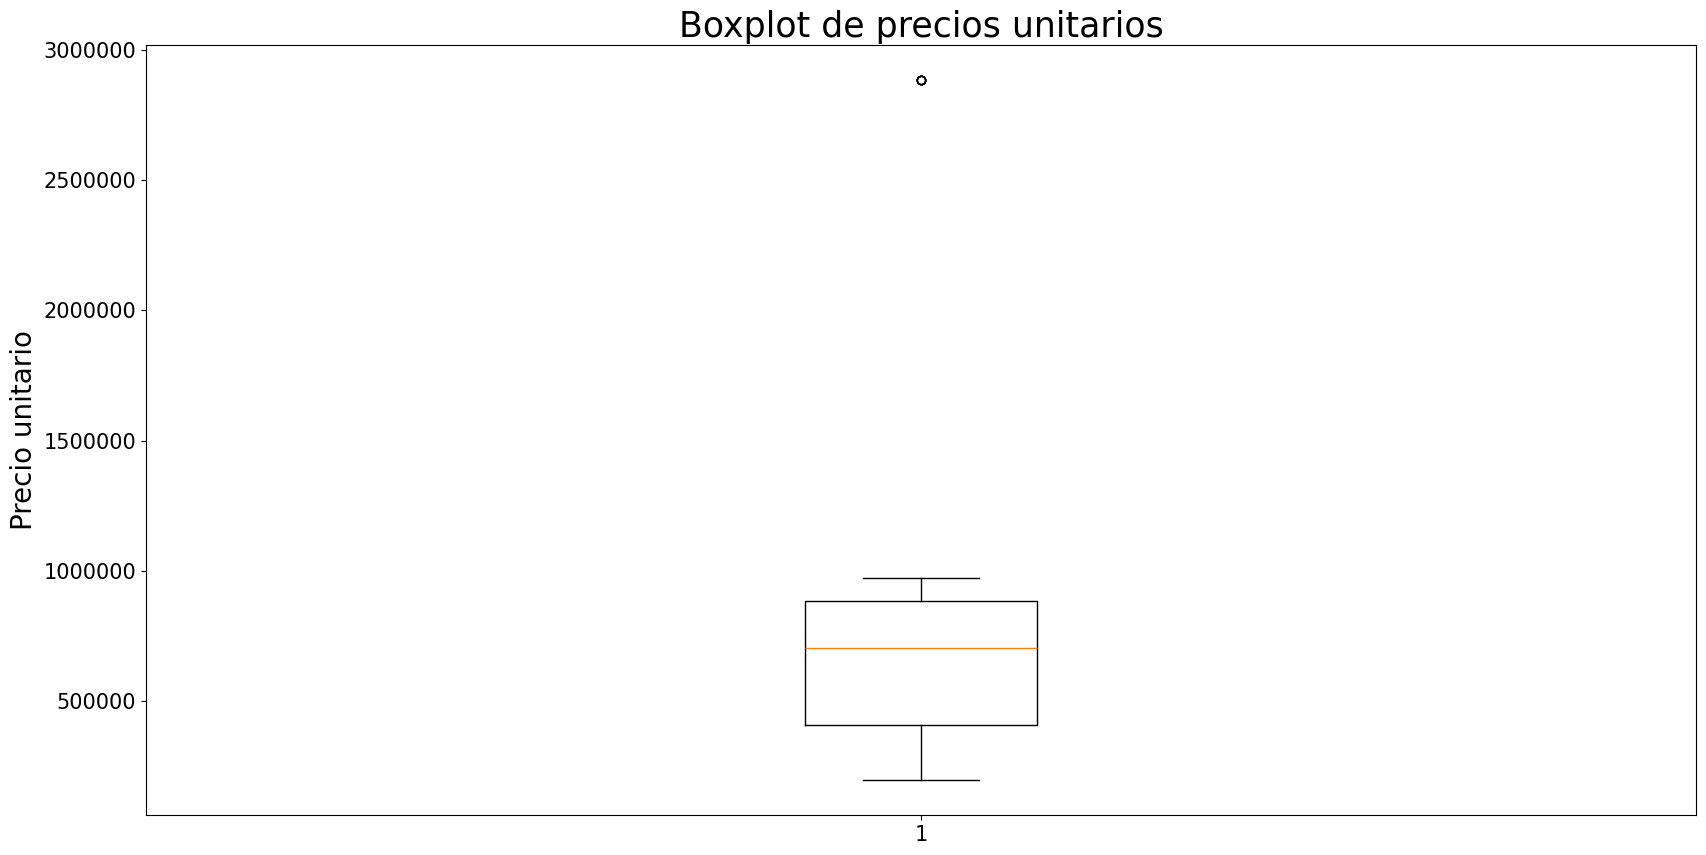

In [90]:
plt.figure( figsize=(20, 10) )
plt.boxplot( df_EDA["precio_unitario"])
plt.ticklabel_format(style="plain", axis="y")
plt.title("Boxplot de precios unitarios", fontsize=25)
plt.ylabel("Precio unitario", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoBoxplot1.png", dpi=300, bbox_inches='tight')
plt.show()

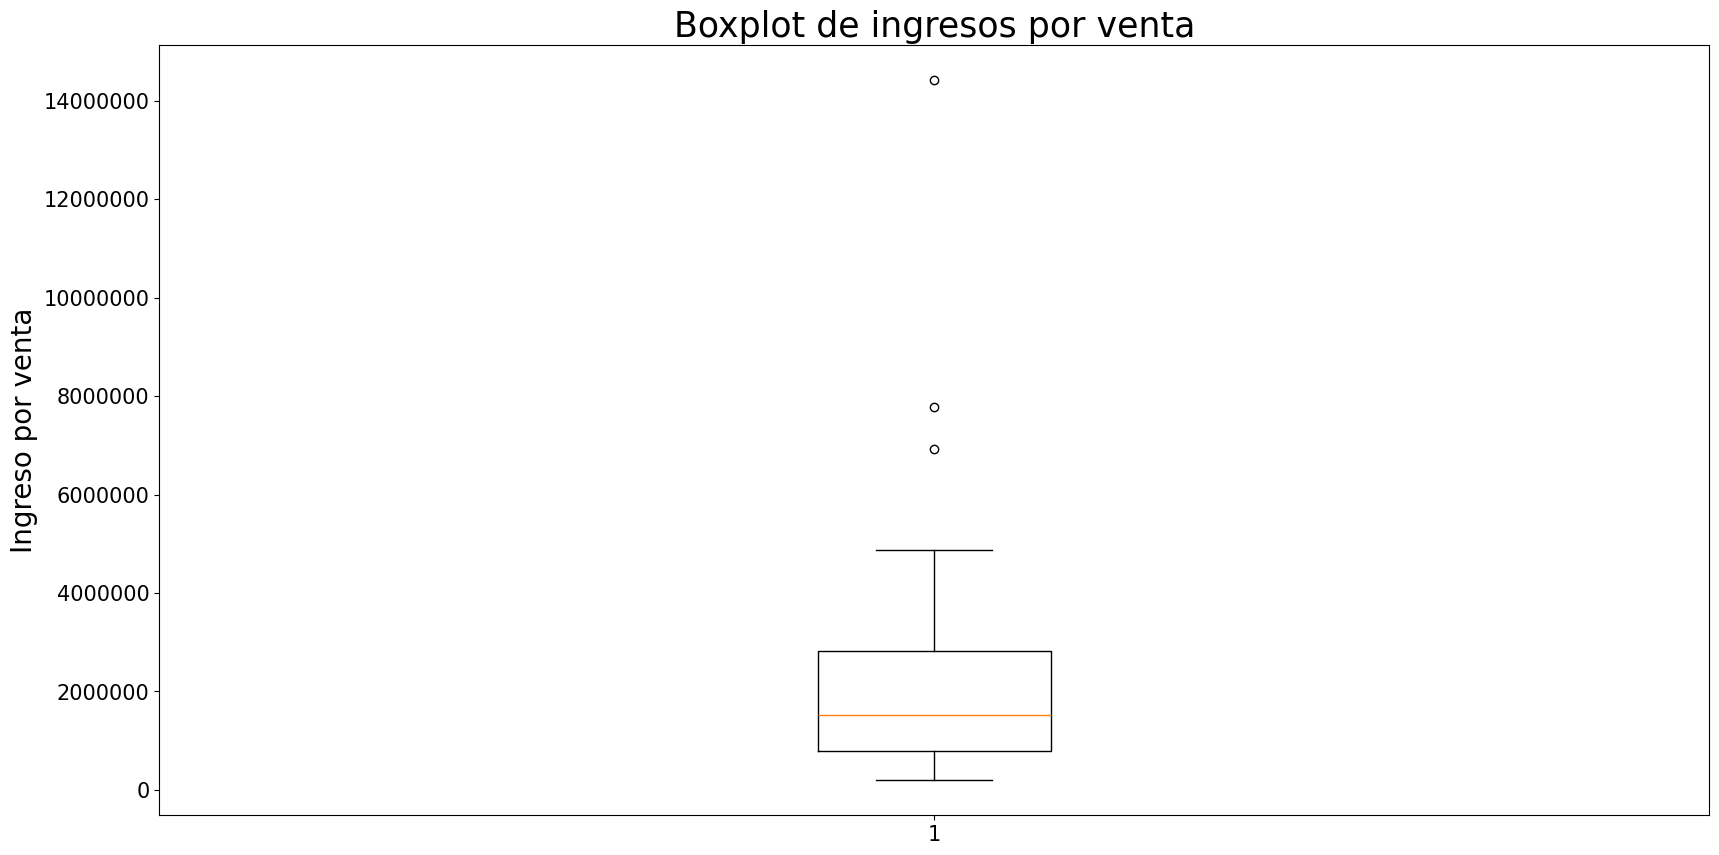

In [91]:
plt.figure( figsize=(20, 10))
plt.boxplot( df_EDA["ingreso_venta"] )
plt.ticklabel_format(style="plain", axis="y")
plt.title("Boxplot de ingresos por venta", fontsize=25)
plt.ylabel("Ingreso por venta", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoBoxplot2.png", dpi=300, bbox_inches='tight')
plt.show()

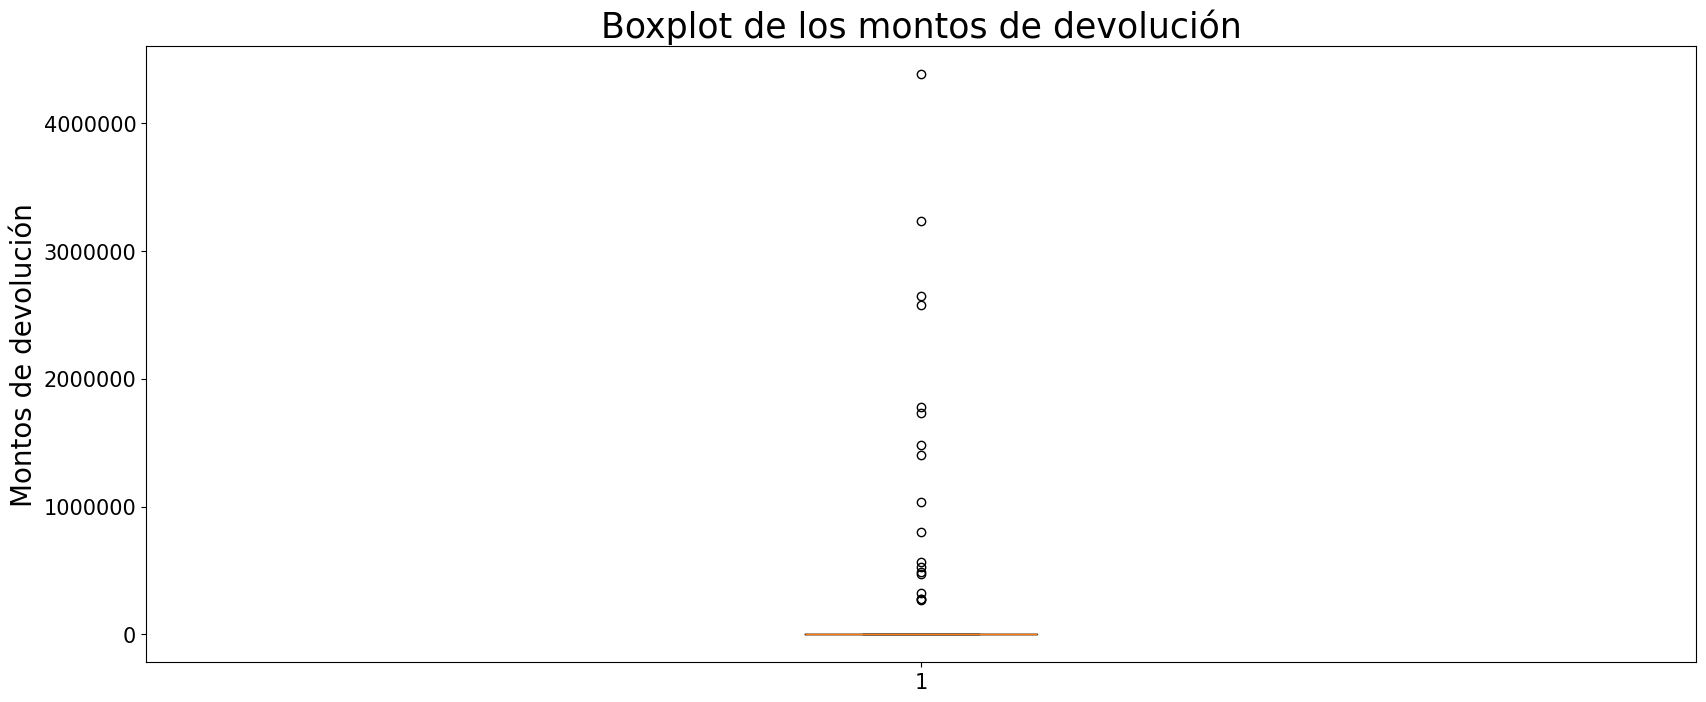

In [92]:
plt.figure( figsize=(20, 8) )
plt.boxplot( df_EDA["monto_devolucion"])
plt.ticklabel_format(style="plain", axis="y")
plt.title("Boxplot de los montos de devolución", fontsize=25)
plt.ylabel("Montos de devolución", fontsize=20)
plt.tick_params(axis="both", labelsize=15)
plt.savefig("GráficoBoxplot3.png", dpi=300, bbox_inches='tight')
plt.show()

#### **Identificar valores atípicos y documentar su impacto**

In [93]:
#METODO IQR
def calcular_IQR(df, columna):
    #Calcular cuartil 1 y 3
    Q1 = df[columna].quantile(0.25)   # Primer cuartil 25%
    Q3 = df[columna].quantile(0.75)   # Tercer cuartil 75%

    #Rango intercuartiles (IQR)
    IQR = Q3 - Q1

    #Límites superior e inferior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    #DataFrame con las filas que están fuera de los límites
    df_outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    
    print(f"Registros con Outliers detectados en {columna} con IQR : {df_outliers.shape[0]}\n Límite inferior: {limite_inferior}   Límite superior: {limite_superior} \n")

    return   df_outliers, limite_inferior, limite_superior


#METODO Z-score
def calcular_Zscore(df, columna):
    from scipy.stats import zscore
    df_zscore=df.copy()
    df_zscore["z_score"] = zscore(df[columna])
    df_outliers = df_zscore[(df_zscore["z_score"] > 3) | (df_zscore["z_score"] < -3)]

    return print(f"Registros con Outliers detectados en {columna} con Z-score: {df_outliers.shape[0]}")


In [94]:
print("\033[1m Outliers con IQR\033[0m\n")
outliers1, li1, ls1 = calcular_IQR(df_EDA, "precio_unitario")
outliers2, li2, ls2 = calcular_IQR(df_EDA, "ingreso_venta")
outliers3, li3, ls3 = calcular_IQR(df_EDA, "monto_devolucion")


print("\n\033[1m Outliers con Z-score\033[0m")
calcular_Zscore(df_EDA, "precio_unitario")
calcular_Zscore(df_EDA, "ingreso_venta")
calcular_Zscore(df_EDA, "monto_devolucion")


 Outliers con IQR

Registros con Outliers detectados en precio_unitario con IQR : 5
 Límite inferior: -299557.5   Límite superior: 1593830.5 

Registros con Outliers detectados en ingreso_venta con IQR : 3
 Límite inferior: -2264576.5   Límite superior: 5874259.5 

Registros con Outliers detectados en monto_devolucion con IQR : 18
 Límite inferior: 0.0   Límite superior: 0.0 


 Outliers con Z-score
Registros con Outliers detectados en precio_unitario con Z-score: 5
Registros con Outliers detectados en ingreso_venta con Z-score: 3
Registros con Outliers detectados en monto_devolucion con Z-score: 6


Tras la identificación de valores atípicos de forma visual en boxplot y matemática con IQR y Z-score, se concluye que:

- En precio_unitario, los outliers tienen un valor sobre los rangos de precio unitario determinados para los productos (entre diez mil y un millón), lo cual podría deberse a un error al momento de registrar el precio. Estos datos tienen como efecto alterar los valores de los datos de la estadística descriptiva de precio_unitario. Asimismo, impactan en los valores de columnas como ingreso_venta y monto_devolucion que dependen de este para su cálculo.

- En ingreso_venta, los valores atípicos pudieron generarse por los outliers de precio_unitario, ya que, los ingresos por venta son el resultado de la multiplicación entre cantidad, el precio unitario y el descuento.

- En monto_devolucion, la evidencia recopilada da como muestra la existencia de outliers. Sin embargo, hay que tener en cuenta que la naturaleza de esta columna es dar el monto del dinero a devolver al cliente por su insatisfacción con el producto. 
Por lo cual se supone que, esta situación debe ocurrir con baja frecuencia y que notablemente va a contrastar con la mayoría de los casos en que no se solicitó la devolución (monto de devolución igual a cero).
Además, al igual que en ingreso_venta, los valores de monto_devolucion podrían haberse influenciado por los outliers de precio_unitario debido a que están relacionados implícitamente en la fórmula de cálculo del monto de dinero a devolver.


In [95]:
#Generar copia para L3
df_L3 = df_EDA.copy()

### **Lección 3: CORRELACIÓN**

#### **Construir scatterplots y matrices de correlación**

##### Scatterplots

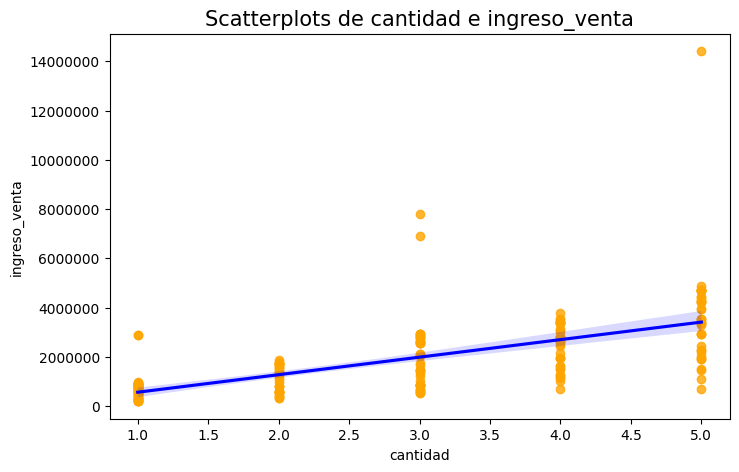

In [96]:
plt.figure( figsize=(8,5))
sns.regplot(data=df_L3, x="cantidad", y="ingreso_venta", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.ticklabel_format(style="plain", axis="y")
plt.title("Scatterplots de cantidad e ingreso_venta", fontsize=15)
plt.savefig("GráficoScatterplots1.png", dpi=300, bbox_inches='tight')
plt.show()

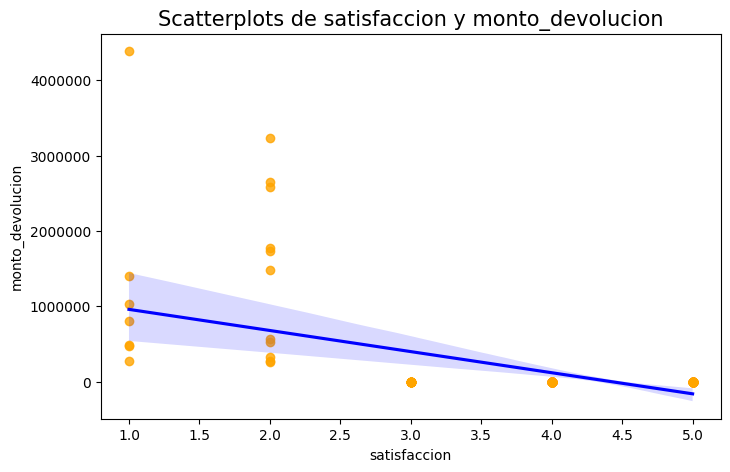

In [97]:
plt.figure( figsize=(8,5))
sns.regplot(data=df_L3, x="satisfaccion", y="monto_devolucion", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.ticklabel_format(style="plain", axis="y")
plt.title("Scatterplots de satisfaccion y monto_devolucion", fontsize=15)
plt.savefig("GráficoScatterplots2.png", dpi=300, bbox_inches='tight')
plt.show()

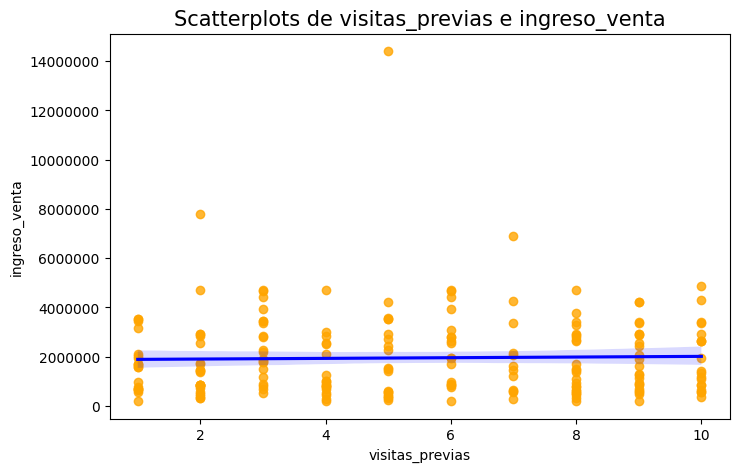

In [98]:
plt.figure( figsize=(8,5))
sns.regplot(data=df_L3, x="visitas_previas", y="ingreso_venta", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.ticklabel_format(style="plain", axis="both")
plt.title("Scatterplots de visitas_previas e ingreso_venta", fontsize=15)
plt.savefig("GráficoScatterplots3.png", dpi=300, bbox_inches='tight')
plt.show()

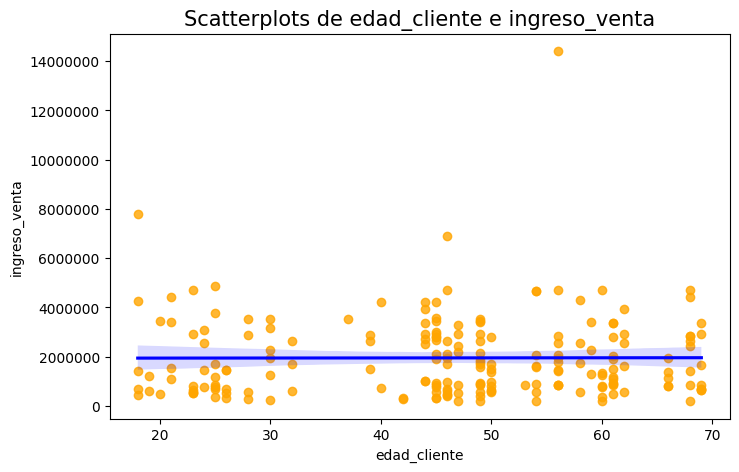

In [99]:
plt.figure( figsize=(8,5))
sns.regplot(data=df_L3, x="edad_cliente", y="ingreso_venta", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.ticklabel_format(style="plain", axis="both")
plt.title("Scatterplots de edad_cliente e ingreso_venta", fontsize=15)
plt.savefig("GráficoScatterplots4.png", dpi=300, bbox_inches='tight')
plt.show()

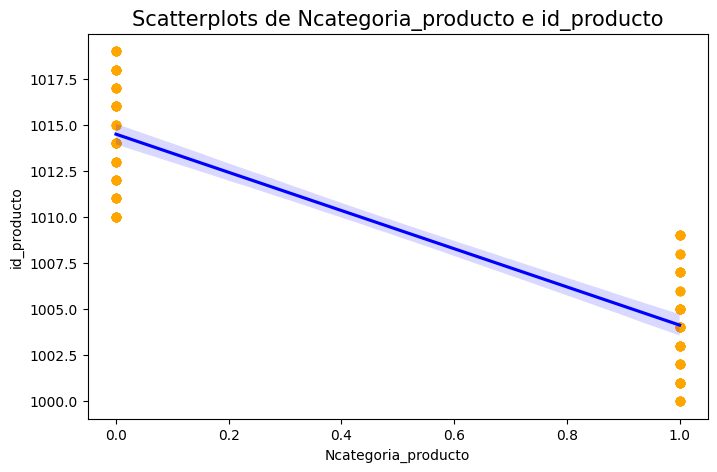

In [100]:
plt.figure( figsize=(8,5))
sns.regplot(data=df_L3, x="Ncategoria_producto", y="id_producto", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.ticklabel_format(style="plain", axis="both")
plt.title("Scatterplots de Ncategoria_producto e id_producto", fontsize=15)
plt.savefig("GráficoScatterplots5.png", dpi=300, bbox_inches='tight')
plt.show()

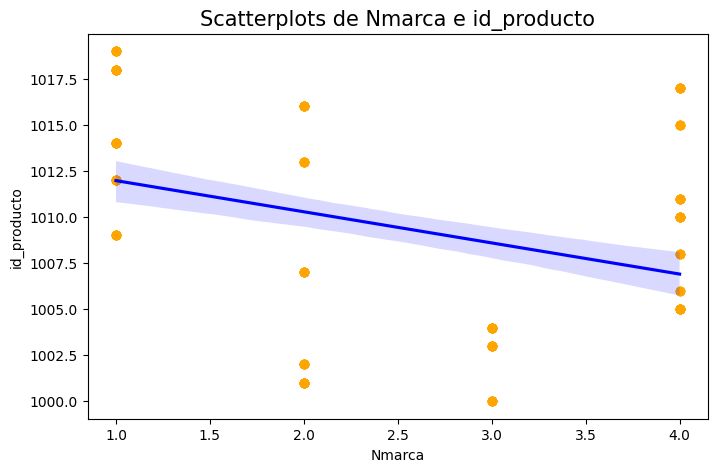

In [101]:
plt.figure( figsize=(8,5))
sns.regplot(data=df_L3, x="Nmarca", y="id_producto", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.ticklabel_format(style="plain", axis="both")
plt.title("Scatterplots de Nmarca e id_producto", fontsize=15)
plt.savefig("GráficoScatterplots6.png", dpi=300, bbox_inches='tight')
plt.show()

##### Matriz de correlación

In [102]:
df_L3_num = df_L3.select_dtypes(include=["float64", "int32", "int64"]).drop(columns=["id_transaccion"])
df_L3_num.corr()

,id_producto,cantidad,descuento_aplicado,visitas_previas,devolucion,satisfaccion,edad_cliente,precio_unitario,ingreso_venta,monto_devolucion,Ngenero_cliente,Ncanales_venta,Ncategoria_producto,Nregion,Nmarca,Nmes
id_producto,1.000000,0.149232,0.061640,0.105879,0.028913,-0.053025,0.052339,-0.082479,0.036191,0.112697,0.065616,0.049919,-0.880764,0.176609,-0.343627,0.076544
cantidad,0.149232,1.000000,-0.051184,0.048664,-0.037397,0.105633,0.039366,0.018009,0.631880,0.069454,-0.028189,0.067803,-0.118857,0.065790,-0.070638,-0.056570
descuento_aplicado,0.061640,-0.051184,1.000000,0.075734,0.087349,-0.046037,-0.031439,-0.035413,-0.173990,-0.013931,-0.013711,-0.028269,-0.075677,0.004341,0.041737,0.010307
visitas_previas,0.105879,0.048664,0.075734,1.000000,0.089705,-0.077744,-0.038054,0.030637,0.024376,0.080777,-0.042394,0.049779,-0.065560,0.029270,-0.005755,0.086675
devolucion,0.028913,-0.037397,0.087349,0.089705,1.000000,-0.740791,-0.077049,0.001041,-0.022990,0.743654,-0.114123,-0.099127,-0.057352,0.002993,-0.090502,-0.013545
satisfaccion,-0.053025,0.105633,-0.046037,-0.077744,-0.740791,1.000000,0.122043,0.055951,0.123379,-0.545364,0.109146,0.025929,0.059063,0.035831,0.103206,-0.011637
edad_cliente,0.052339,0.039366,-0.031439,-0.038054,-0.077049,0.122043,1.000000,-0.036621,0.002820,-0.021362,0.113392,0.025372,-0.059827,-0.163427,-0.052225,-0.014336
precio_unitario,-0.082479,0.018009,-0.035413,0.030637,0.001041,0.055951,-0.036621,1.000000,0.675039,0.091502,-0.104440,0.068108,0.124548,0.089687,0.040302,-0.033950
ingreso_venta,0.036191,0.631880,-0.173990,0.024376,-0.022990,0.123379,0.002820,0.675039,1.000000,0.130728,-0.063146,0.040137,0.002912,0.109375,-0.030647,-0.035328
monto_devolucion,0.112697,0.069454,-0.013931,0.080777,0.743654,-0.545364,-0.021362,0.091502,0.130728,1.000000,-0.119038,-0.010439,-0.132997,0.115563,-0.071442,-0.060095


#### **Calcular el coeficiente de Pearson (R)**

In [103]:
# Coeficiente de Pearson entre cantidad e ingreso_venta 
r1 = df_L3_num["cantidad"].corr( df_L3_num["ingreso_venta"] )
print("Coeficiente de Pearson entre cantidad e ingreso_venta: ",round(r1,3))  

# Coeficiente de Pearson entre satisfaccion y monto_devolucion 
r2 = df_L3_num["satisfaccion"].corr( df_L3_num["monto_devolucion"] )
print("\nCoeficiente de Pearson entre satisfaccion y monto_devolucion: ",round(r2,3))  

# Coeficiente de Pearson entre devolucion y monto_devolucion
r3 = df_L3_num["devolucion"].corr( df_L3_num["monto_devolucion"] )
print("\nCoeficiente de Pearson entre devolucion y monto_devolucion: ",round(r3,3))  

# Coeficiente de Pearson entre satisfaccion y devolucion 
r4 = df_L3_num["satisfaccion"].corr( df_L3_num["devolucion"] )
print("\nCoeficiente de Pearson entre satisfaccion y devolucion: ",round(r4,3)) 

# Coeficiente de Pearson entre Ncategoria_producto e id_producto 
r5 = df_L3_num["Ncategoria_producto"].corr( df_L3_num["id_producto"] )
print("\nCoeficiente de Pearson entre Ncategoria_producto e id_producto: ",round(r5,3)) 

# Coeficiente de Pearson entre Nmarca e id_producto
r6 = df_L3_num["Nmarca"].corr( df_L3_num["id_producto"] )
print("\nCoeficiente de Pearson entre Nmarca e id_producto: ",round(r6,3))

Coeficiente de Pearson entre cantidad e ingreso_venta:  0.632

Coeficiente de Pearson entre satisfaccion y monto_devolucion:  -0.545

Coeficiente de Pearson entre devolucion y monto_devolucion:  0.744

Coeficiente de Pearson entre satisfaccion y devolucion:  -0.741

Coeficiente de Pearson entre Ncategoria_producto e id_producto:  -0.881

Coeficiente de Pearson entre Nmarca e id_producto:  -0.344


#### **Detectar correlaciones espurias y justificar**

Con las actividades anteriores realizadas, se detecta que hay presencia de correlación espuria en relaciones como Ncategoria_producto e id_producto y Nmarca e id_producto que presentan una alta correlación negativa, es decir, una relación negativa entre variables.

Sumado a esto, se consideran también las correlaciones espurias todas aquellas que se realicen con las variables de ID (id_producto) o que representan a una variable categórica transformada a cuantitativa (Nmarca, Ngenero_cliente, Ncanales_venta, Ncategoria_producto, Nregion y Nmes). 

Esto se debe a que no representan valores reales sino una asignación numérica arbitraria que no implica un orden real ni causalidad.


In [104]:
#Copia de df_L3_num

df_L3_num=df_L3_num.drop(columns=["id_producto"])
df_reg= df_L3_num.copy()


### **Lección 4: REGRESIONES LINEALES**

In [105]:
#Reacondicionar columnas para regreción lineal
df_reg = df_reg.rename(columns={"Ngenero_cliente": "genero_cliente_F"})
df_reg = df_reg.rename(columns={"Ncanales_venta": "canal_web"})
df_reg = df_reg.rename(columns={"Ncategoria_producto": "categoria_Tecno"})

#### **Aplicar modelos con statsmodels**

##### Regresión lineal simple

In [106]:
#Regresión entre visitas_previas y satisfaccion
x1 = sm.add_constant(df_reg["visitas_previas"])
y1 = df_reg["satisfaccion"]
modeloS1 = sm.OLS(y1,x1).fit()

#print(modeloS1.params)
print(modeloS1.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaccion   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.204
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.274
Time:                        02:09:20   Log-Likelihood:                -285.15
No. Observations:                 200   AIC:                             574.3
Df Residuals:                     198   BIC:                             580.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1354      0.151     

In [107]:
#Regresión entre edad_cliente y cantidad
x2 = sm.add_constant(df_reg["edad_cliente"])
y2 = df_reg["cantidad"]
modeloS2 = sm.OLS(y2,x2).fit()

#print(modeloS2.params)
print(modeloS2.summary())

                            OLS Regression Results                            
Dep. Variable:               cantidad   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.3073
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.580
Time:                        02:09:21   Log-Likelihood:                -357.71
No. Observations:                 200   AIC:                             719.4
Df Residuals:                     198   BIC:                             726.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.7706      0.340      8.161   

##### Regresión lineal múltiple

In [108]:
#Regresión entre visitas_previas, edad_cliente, devolucion, genero_cliente_F y satisfaccion
x3 = sm.add_constant(df_reg[["visitas_previas","edad_cliente", "devolucion", "genero_cliente_F"]])
y3 = df_reg["satisfaccion"]
modeloM3 = sm.OLS(y3,x3).fit()

#print(modeloM3.params)
print(modeloM3.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaccion   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     60.41
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           4.03e-33
Time:                        02:09:21   Log-Likelihood:                -205.14
No. Observations:                 200   AIC:                             420.3
Df Residuals:                     195   BIC:                             436.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.0238      0.189  

In [109]:
#Regresión entre descuento_aplicado, cantidad, canal_web, categoria_Tecno e ingreso_venta
x4 = sm.add_constant(df_reg[["descuento_aplicado","cantidad","canal_web","categoria_Tecno"]])
y4 = df_reg["ingreso_venta"]
modeloM4 = sm.OLS(y4,x4).fit()

#print(modeloM4.params)
print(modeloM4.summary())


                            OLS Regression Results                            
Dep. Variable:          ingreso_venta   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     35.87
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.89e-22
Time:                        02:09:21   Log-Likelihood:                -3089.7
No. Observations:                 200   AIC:                             6189.
Df Residuals:                     195   BIC:                             6206.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -1.183e+05   2.76

In [110]:
#Vista amigable de Regresión entre descuento_aplicado, cantidad, canal_web, categoria_Tecno e
#  ingreso_venta

pd.set_option('display.float_format', '{:.4f}'.format)

resumen = modeloM4.summary2()

for i, t in enumerate(resumen.tables):
    print(f"Tabla {i}")
    print(t.to_string())
    print("\n")


pd.reset_option('display.float_format')


Tabla 0
                     0                 1                    2           3
0               Model:               OLS      Adj. R-squared:       0.412
1  Dependent Variable:     ingreso_venta                 AIC:   6189.3957
2                Date:  2026-03-12 02:09                 BIC:   6205.8872
3    No. Observations:               200      Log-Likelihood:     -3089.7
4            Df Model:                 4         F-statistic:       35.87
5        Df Residuals:               195  Prob (F-statistic):    1.89e-22
6           R-squared:             0.424               Scale:  1.5737e+12


Tabla 1
                           Coef.    Std.Err.       t  P>|t|        [0.025       0.975]
const               -118319.5038 275563.8044 -0.4294 0.6681  -661787.5552  425148.5475
descuento_aplicado -2137196.0514 855664.7884 -2.4977 0.0133 -3824741.6136 -449650.4892
cantidad             713252.0835  61894.5028 11.5237 0.0000   591183.4944  835320.6726
canal_web             -1503.7489 194808.57

#### **Calcular R², MSE, MAE**

In [111]:
# R², MSE, MAE de modelo de regresión lineal simple 1
predicciones_S1 = modeloS1.predict(x1)
print("MAE: ", mean_absolute_error(y1, predicciones_S1))
print("MSE: ", mean_squared_error(y1, predicciones_S1))
print("R2: ", r2_score(y1, predicciones_S1))

MAE:  0.7264293332096818
MSE:  1.0137356255216545
R2:  0.006044096949059163


In [112]:
# R², MSE, MAE de modelo de regresión lineal simple 2
predicciones_S2 = modeloS2.predict(x2)
print("MAE: ", mean_absolute_error(y2, predicciones_S2))
print("MSE: ", mean_squared_error(y2, predicciones_S2))
print("R2: ", r2_score(y2, predicciones_S2))


MAE:  1.2299954994542481
MSE:  2.0942496108541975
R2:  0.0015496491755911945


In [113]:
# R², MSE, MAE de modelo de regresión lineal múltiple 3
predicciones_M3 = modeloM3.predict(x3)
print("MAE: ", mean_absolute_error(y3, predicciones_M3))
print("MSE: ", mean_squared_error(y3, predicciones_M3))
print("R2: ", r2_score(y3, predicciones_M3))

MAE:  0.5747690052450644
MSE:  0.45546893732597155
R2:  0.5534180436062638


In [114]:
# R², MSE, MAE de modelo de regresión lineal múltiple 4
predicciones_M4 = modeloM4.predict(x4)
print("MAE: ", mean_absolute_error(y4, predicciones_M4))
print("MSE: ", mean_squared_error(y4, predicciones_M4))
print("R2: ", r2_score(y4, predicciones_M4))

MAE:  716767.89750024
MSE:  1534309015469.0505
R2:  0.4238923288852814


#### **Evaluar significancia de predictores**

En el primer modelo, visitas_previas no es significativo, ya que, su p-value no es menor a 0,05.

En el segundo modelo, edad_cliente no es significativo porque tiene un p-value de 0,580 que es mayor a 0,05.

En el tercer modelo, visitas_previas, edad_cliente y genero_cliente_F no son significativos debido a que tienen un p-value superior a 0,05. Solo devolucion es significativo con un p-value de 0,000.

En el cuarto modelo, canal_web y categoria_Tecno son no significativas por presentar un p-value superior a 0,05. Por otro lado, descuento_aplicado y cantidad son significativas con un p-value de 0,013 y 0,000 respectivamente.


#### **Interpretar coeficientes e inferencias básicas**

En el primer modelo, la relación entre visitas_previas y satisfaccion es negativa, lo cual se traduce en que, por una visita previa, la satisfacción disminuye en 0.0267 puntos en promedio.

En el segundo modelo, la relación entre edad_cliente y cantidad es positiva. Sin embargo, esta relación es muy debil, es decir que, por cada año adicional en la edad del cliente, la cantidad comprada aumenta en 0.0039 unidades en promedio.

En el tercer modelo, se observa que las variables independientes de visitas_previas, edad_cliente y genero_cliente_F no tienen gran significancia en la satisfaccion influyendo en -0.0030 puntos si hay una visita previa adicional, aumenta 0.0043 puntos por cada año adicional en la edad del cliente y aumenta 0.0370 por cada cliente sexo femenino. En contraparte, está la variable devolucion que presenta un gran efecto en satisfacción, lo cual se ve reflejado en que cuando hay devolución, la satisfacción baja en 2.59 puntos aproximados, manteniendo todo lo demás constante.

En el cuarto modelo, las variables de canal_web y categoria_Tecno no muestran ser tan significativas en ingreso_venta originando una disminución de $1504 si el canal de venta es la página web y un aumento de $221.402 si la categoría de producto es Tecnología. Por otro lado, la variable cantidad tiene un impacto fuerte en ingreso_venta al provocar que cada unidad vendida adicional aumenta el ingreso por venta en $713.252 aproximadamente. También, se ve que descuento_aplicado influye negativamente en ingreso_venta generando una disminución de $2.137.196 en promedio.

#### **Visualizar la regresión con Seaborn**

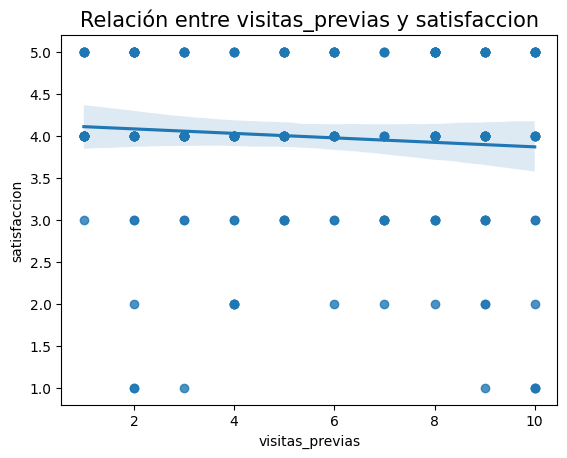

In [115]:
# Modelo 1
sns.regplot(x="visitas_previas", y="satisfaccion" , data=df_reg )
plt.title("Relación entre visitas_previas y satisfaccion", fontsize=15)
plt.savefig("GráficoRelación1Modelo1.png", dpi=300, bbox_inches='tight')
plt.show()

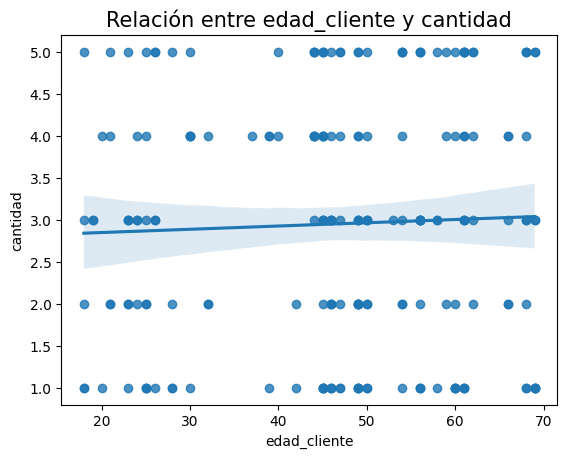

In [116]:
# Modelo 2
sns.regplot(x="edad_cliente", y="cantidad" , data=df_reg )
plt.title("Relación entre edad_cliente y cantidad", fontsize=15)
plt.savefig("GráficoRelación1Modelo2.png", dpi=300, bbox_inches='tight')
plt.show()


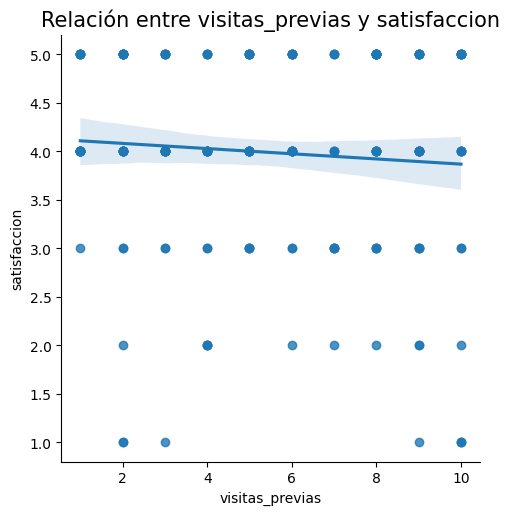

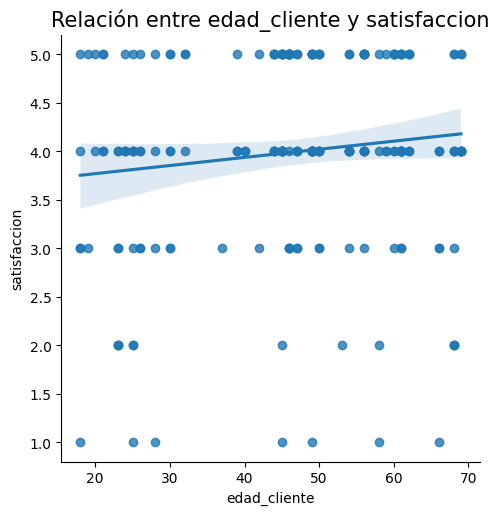

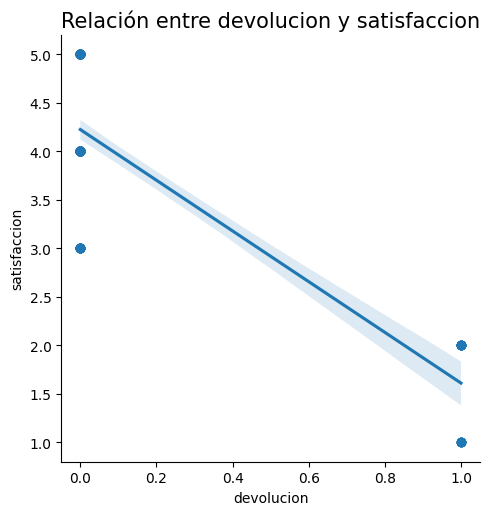

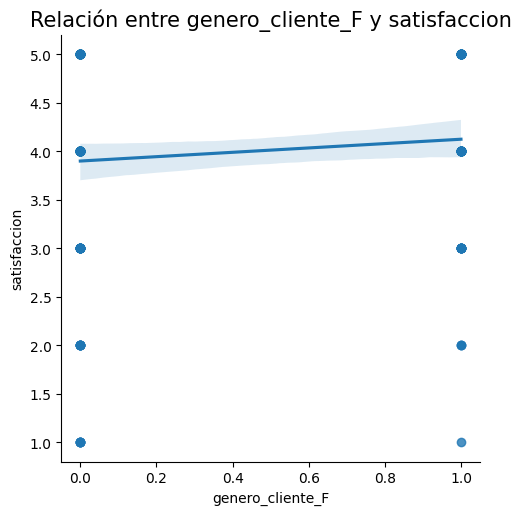

In [117]:
# Modelo 3: Visualización por cada variable independiente

sns.lmplot(x="visitas_previas", y="satisfaccion", data=df_reg)
plt.title("Relación entre visitas_previas y satisfaccion", fontsize=15)
plt.savefig("GráficoRelación1Modelo3.png", dpi=300, bbox_inches='tight')
plt.show()

sns.lmplot(x="edad_cliente", y="satisfaccion", data=df_reg)
plt.title("Relación entre edad_cliente y satisfaccion", fontsize=15)
plt.savefig("GráficoRelación2Modelo3.png", dpi=300, bbox_inches='tight')
plt.show()

sns.lmplot(x="devolucion", y="satisfaccion", data=df_reg)
plt.title("Relación entre devolucion y satisfaccion", fontsize=15)
plt.savefig("GráficoRelación3Modelo3.png", dpi=300, bbox_inches='tight')
plt.show()

sns.lmplot(x="genero_cliente_F", y="satisfaccion", data=df_reg)
plt.title("Relación entre genero_cliente_F y satisfaccion", fontsize=15)
plt.savefig("GráficoRelación4Modelo3.png", dpi=300, bbox_inches='tight')
plt.show()

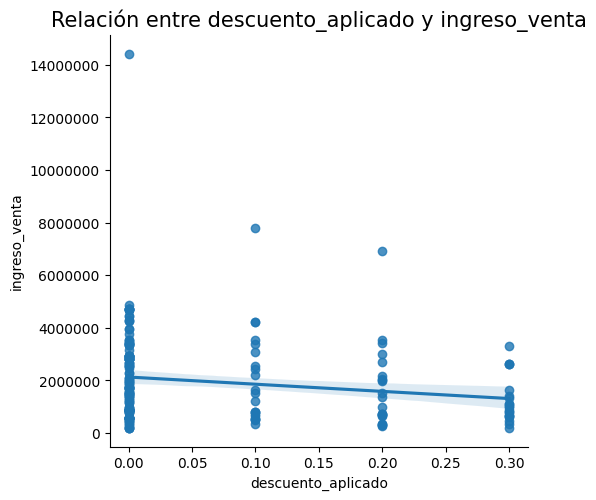

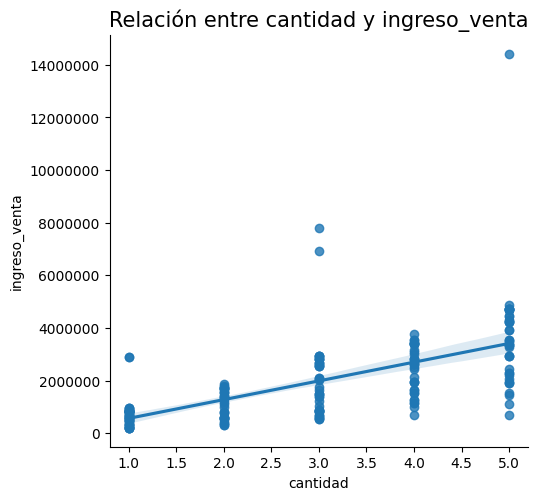

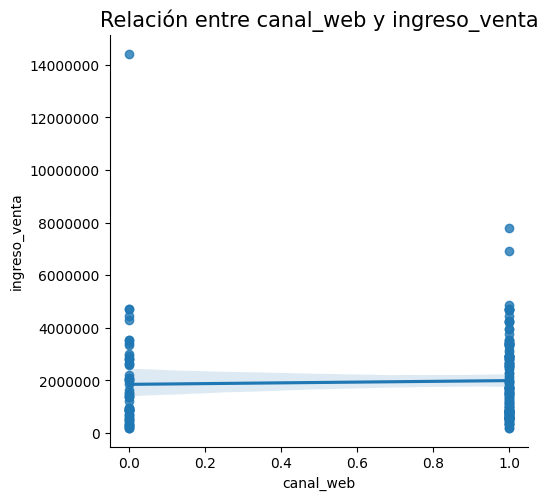

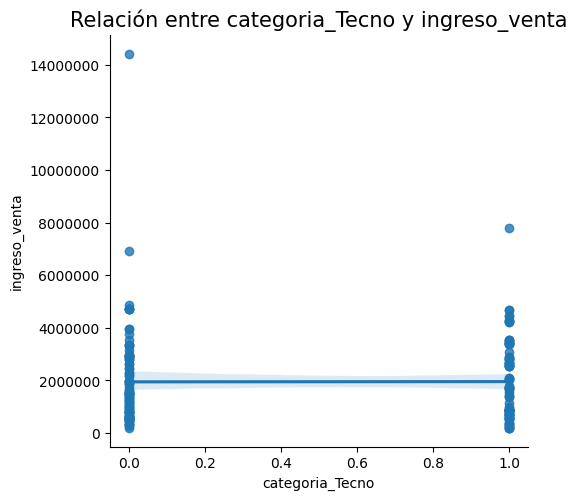

In [118]:
# Modelo 4: Visualización por cada variable independiente

sns.lmplot(x="descuento_aplicado", y="ingreso_venta", data=df_reg)
plt.title("Relación entre descuento_aplicado y ingreso_venta", fontsize=15)
plt.ticklabel_format(style="plain", axis="y")
plt.savefig("GráficoRelación1Modelo4.png", dpi=300, bbox_inches='tight')
plt.show()

sns.lmplot(x="cantidad", y="ingreso_venta", data=df_reg)
plt.title("Relación entre cantidad y ingreso_venta", fontsize=15)
plt.ticklabel_format(style="plain", axis="y")
plt.savefig("GráficoRelación2Modelo4.png", dpi=300, bbox_inches='tight')
plt.show()

sns.lmplot(x="canal_web", y="ingreso_venta", data=df_reg)
plt.title("Relación entre canal_web y ingreso_venta", fontsize=15)
plt.ticklabel_format(style="plain", axis="y")
plt.savefig("GráficoRelación3Modelo4.png", dpi=300, bbox_inches='tight')
plt.show()

sns.lmplot(x="categoria_Tecno", y="ingreso_venta", data=df_reg)
plt.title("Relación entre categoria_Tecno y ingreso_venta", fontsize=15)
plt.ticklabel_format(style="plain", axis="y")
plt.savefig("GráficoRelación4Modelo4.png", dpi=300, bbox_inches='tight')
plt.show()


In [119]:
#Generar copia
df_vizual=df_reg.copy()

### **Lección 5: ANÁLISIS VISUAL DE DATOS**

#### **Crear gráficos de tipo pairplot, violinplot, jointplot y heatmap**

##### Gráfico de tipo pairplot

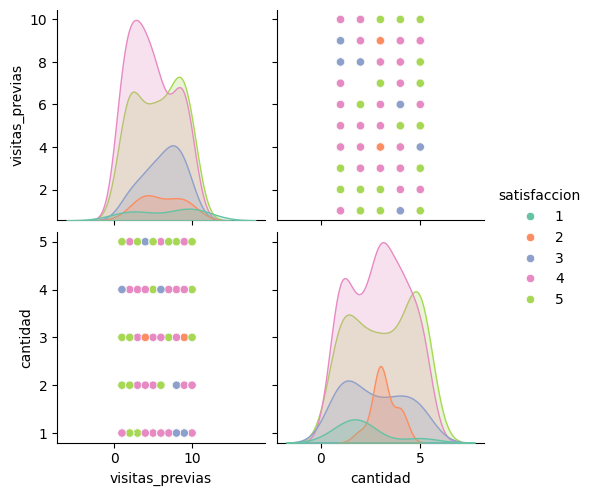

In [120]:
sns.pairplot(df_vizual[["visitas_previas", "satisfaccion","cantidad"]],hue="satisfaccion", palette="Set2")
plt.savefig("GráficoPairplot.png", dpi=300, bbox_inches='tight')
plt.show()

De este gráfico se observa que las variables de visitas_previas y cantidad no tienen una relación fuerte entre sí. También, que ninguna de estas dos variables separa claramente los niveles de satisfacción.

##### Gráfico de tipo violinplot

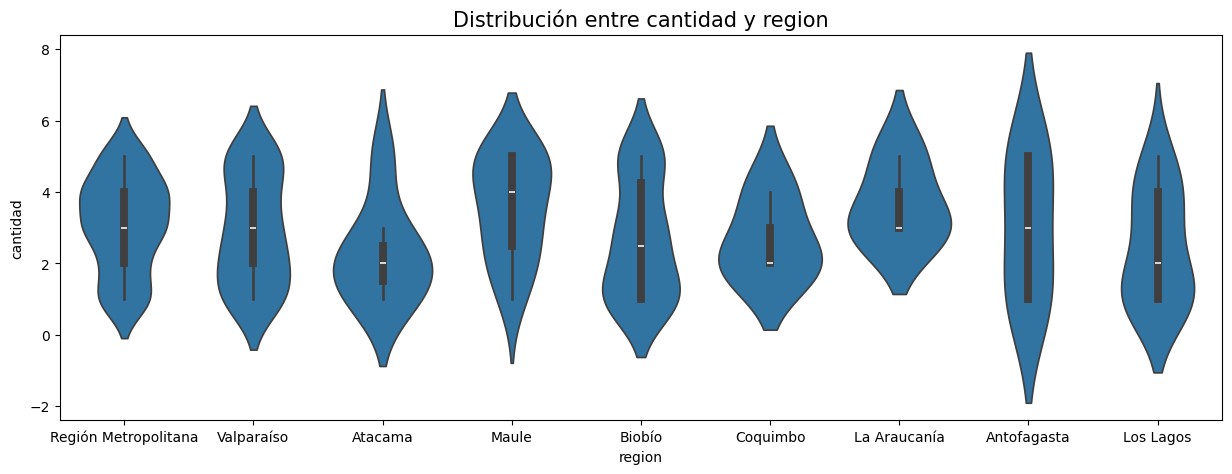

In [121]:
plt.figure(figsize=(15, 5))
sns.violinplot(x="region", y="cantidad",data=df_L3)
plt.title("Distribución entre cantidad y region", fontsize=15)
plt.savefig("GráficoViolinplot.png", dpi=300, bbox_inches='tight')
plt.show()

De este gráfico se obtine que, Antofagasta presenta la mayor variabilidad en cantidad comparada con las demás regiones. Y en varias regiones, la mayor densidad está concentrada en valores bajos de cantidad.

##### Gráfico de tipo jointplot

<Figure size 2000x2000 with 0 Axes>

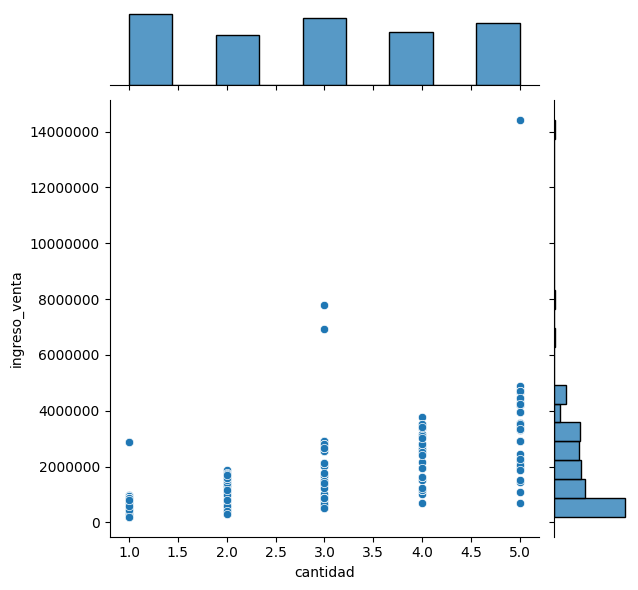

In [122]:
plt.figure(figsize=(20, 20))
sns.jointplot(data=df_vizual, x="cantidad", y="ingreso_venta", kind="scatter")
plt.ticklabel_format(style="plain", axis="y")
plt.savefig("GráficoJoinplot.png", dpi=300, bbox_inches='tight')
plt.show()

Del gráfico de tipo jointplot se destaca que, existen posibles outliers en ingreso_venta y que el histograma de este muestra una concentración en valores bajos y una cola larga hacia arriba.

##### Gráfico de tipo heatmap

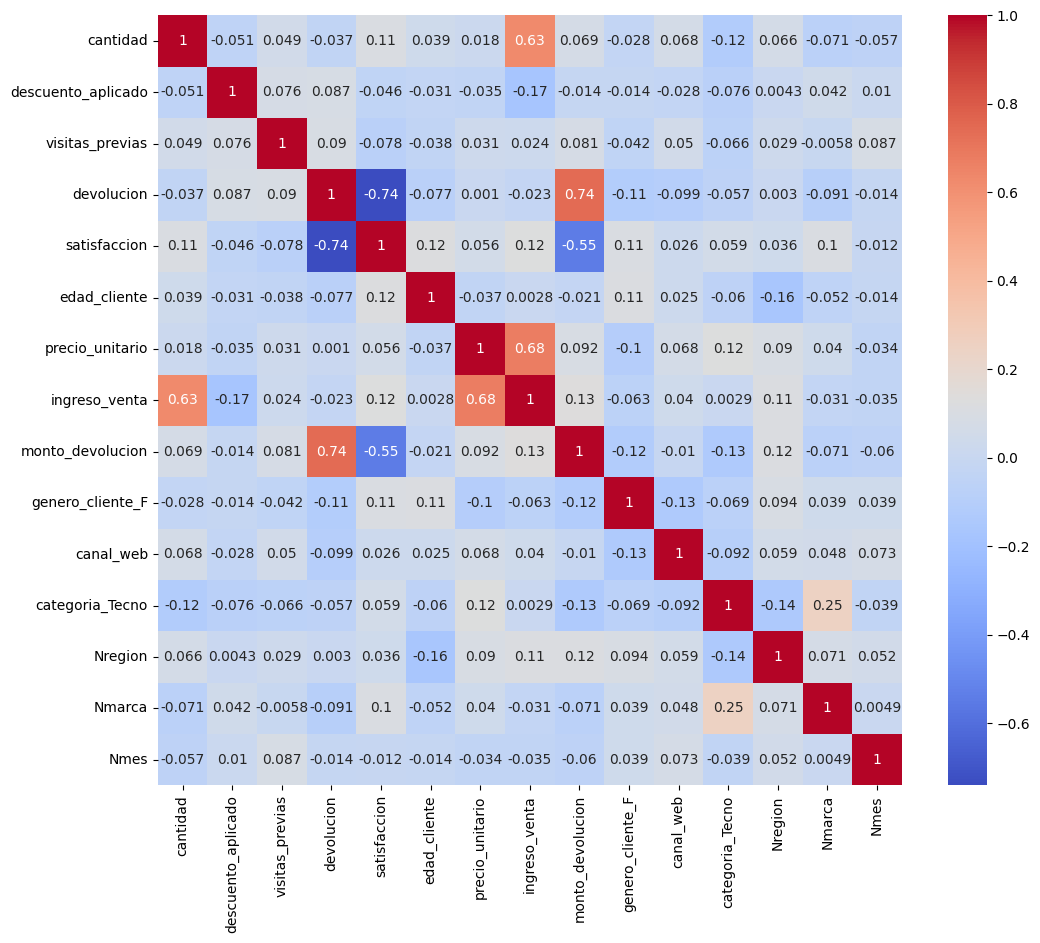

In [123]:
correlacion = df_vizual.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion,annot=True,cmap="coolwarm")

plt.savefig("GráficoHeatmap.png", dpi=300, bbox_inches='tight')

plt.show()

El gráfico de tipo heatmap muestra que las variables de satisfaccion y devolucion tienen una correlación negativa alta, así como también, se presenta en monto_devolucion y satisfaccion.
Por otro lado, existe una correlación positiva alta entre monto_devolucion y devolucion, del mismo modo que, en ingreso_venta y cantidad.

#### **Construir visualizaciones que combinen múltiples variables**

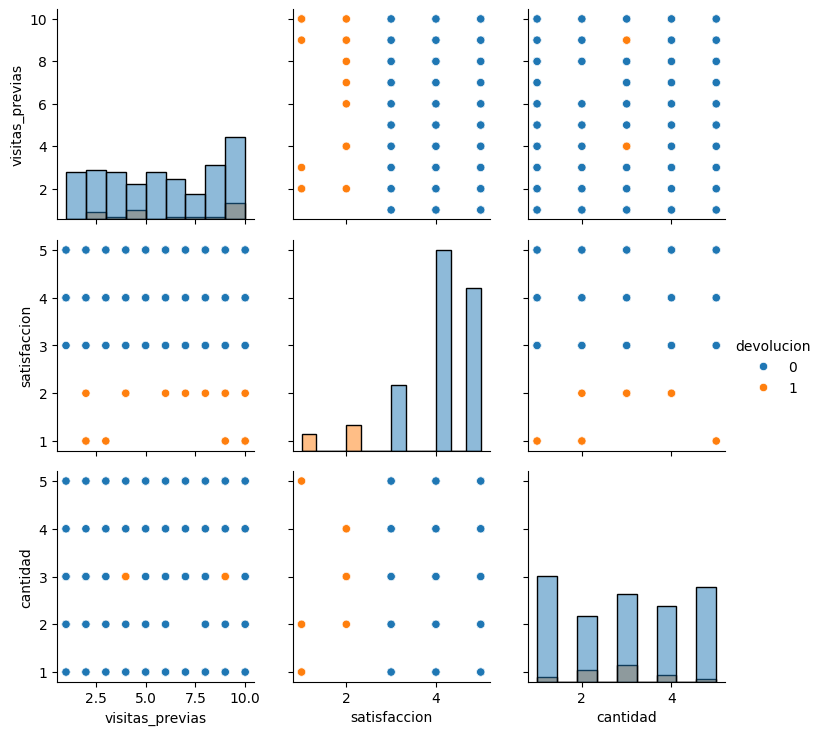

In [124]:
graf_pair=sns.PairGrid(df_vizual[["visitas_previas", "satisfaccion","cantidad","devolucion"]], hue="devolucion")
graf_pair.map_diag(sns.histplot)
graf_pair.map_offdiag(sns.scatterplot)
graf_pair.add_legend()
graf_pair.savefig("GráficoPairGrid.png", dpi=300, bbox_inches='tight')

De este gráfico de múltiples variables se concluye que, satisfaccion es la variable que más se relaciona con devolucion, en cambio, con cantidad y visitas_previas no se presentan patrones distinguibles por sí mismos ni combinados.

#### **Ajustar parámetros de estilo, colores, tamaños**

                         Antes


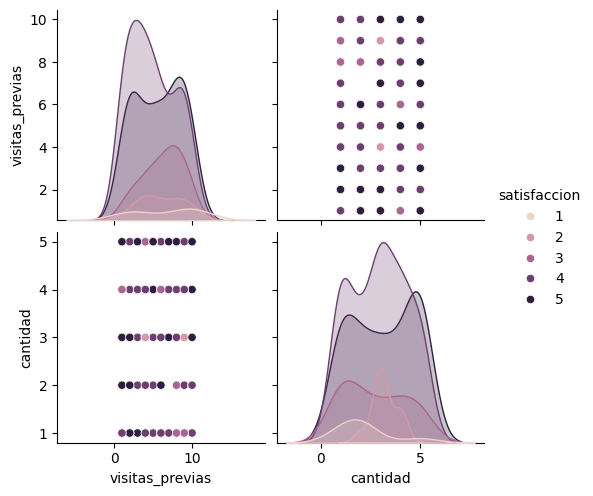


                       Después


<Figure size 1200x500 with 0 Axes>

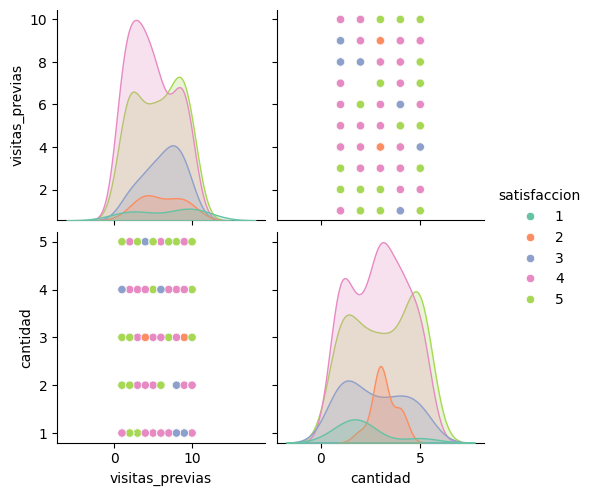

In [125]:
print("                         Antes")
g1= sns.pairplot(df_vizual[["visitas_previas", "satisfaccion","cantidad"]],hue="satisfaccion")
plt.show()

print("\n                       Después")
g2= plt.figure(figsize=(12, 5))
g2=sns.pairplot(df_vizual[["visitas_previas", "satisfaccion","cantidad"]],hue="satisfaccion", palette="Set2")
plt.show()

g1.savefig("ANTESGráficoParámetros.png", dpi=300, bbox_inches='tight')
g2.savefig("DESPUESGráficoParámetros.png", dpi=300, bbox_inches='tight')

#### **Utilizar FacetGrid para segmentar por categorías**

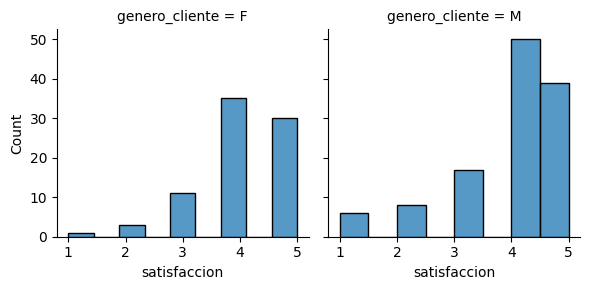

In [126]:
graf_face = sns.FacetGrid(df_L3, col="genero_cliente")
graf_face.map(sns.histplot, "satisfaccion")
graf_face.savefig("GráficoFacetGrid.png", dpi=300, bbox_inches='tight')

En el gráfico con FacetGrid se observa que, la satisfacción sigue la misma forma de distribución tanto para el género femenino como masculino, salvo que la magnitud de estos es diferente, el femenino es menor al masculino.

### **Lección 6: LIBRERÍA MATPLOTLIB**

#### **Crear figuras y subplots, personalizar títulos, etiquetas, leyendas, ticks, usar anotaciones, límites y formatos de archivo**

C:\Users\vinka\AppData\Local\Temp\ipykernel_21804\3037766966.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()


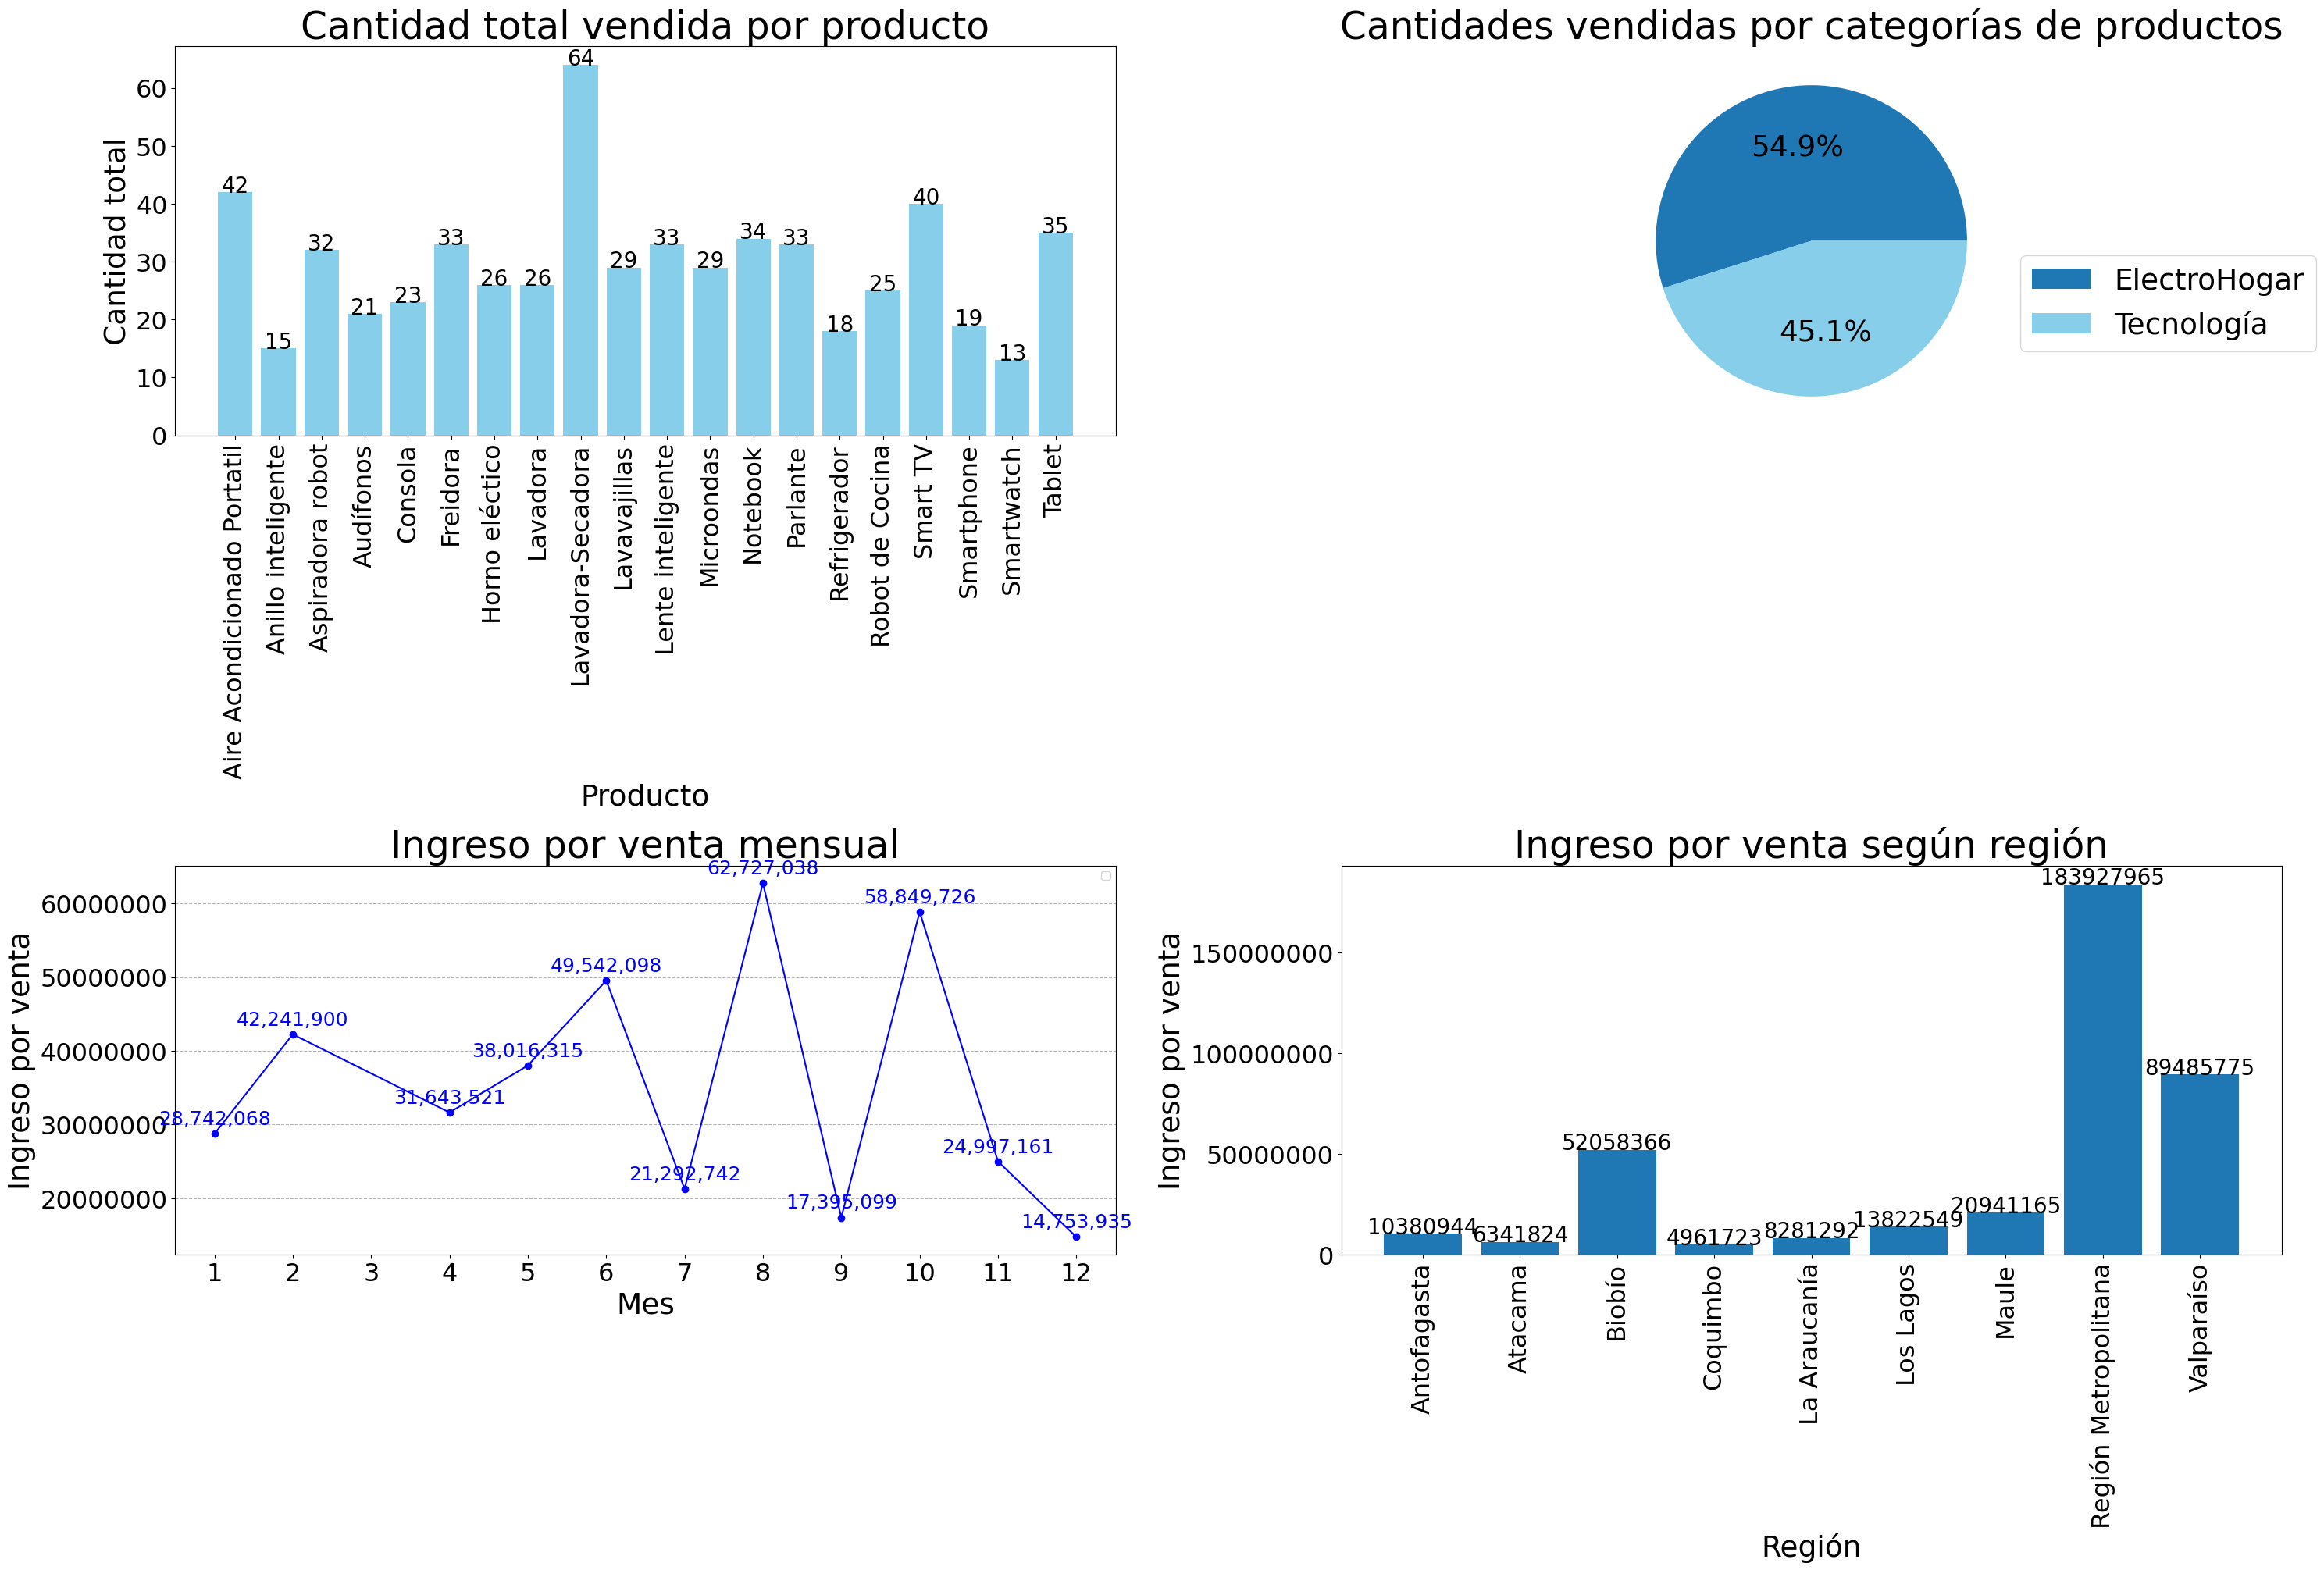

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(30,20), layout="constrained")

# Gráfico 1: barras
df_totales = df_L3.groupby("nombre_producto")["cantidad"].sum().reset_index()

axes[0, 0].bar(df_totales["nombre_producto"], df_totales["cantidad"], color='skyblue')
axes[0, 0].set_title("Cantidad total vendida por producto", fontsize=35)
axes[0, 0].set_xlabel("Producto", fontsize=27)
axes[0, 0].set_ylabel("Cantidad total", fontsize=27)
axes[0, 0].tick_params(axis="x", labelsize=23, rotation=90)
axes[0, 0].tick_params(axis="y", labelsize=23)
for i, v in enumerate(df_totales["cantidad"]):
    axes[0, 0].text(i, v , str(v), ha="center", fontsize=20)

# Gráfico 2: torta
df_totales_2 = df_L3.groupby("categoria_producto")["cantidad"].sum().reset_index()
colores=["#1F77B4","skyblue"]
axes[0,1].pie(df_totales_2["cantidad"],
            labels=None,#df_totales_2["categoria_producto"]
            colors=colores,
            autopct="%1.1f%%", textprops={'fontsize': 27})
axes[0,1].set_title("Cantidades vendidas por categorías de productos", fontsize=35)
axes[0,1].legend(df_totales_2["categoria_producto"], loc="best",fontsize=27, title_fontsize=17,bbox_to_anchor=(1, 0.5))


# Gráfico 3: lineal
df_totales_3 = df_L3.groupby("Nmes")["ingreso_venta"].sum().reset_index()
axes[1, 0].plot( df_totales_3["Nmes"], df_totales_3["ingreso_venta"], marker="o", color='blue' )
axes[1, 0].ticklabel_format(style="plain", axis="y")
axes[1, 0].set_title("Ingreso por venta mensual", fontsize=35)
axes[1, 0].set_xlabel("Mes", fontsize=27)
axes[1, 0].set_xticks(range(0, 13, 1))
axes[1, 0].set_ylabel("Ingreso por venta", fontsize=27)
axes[1, 0].tick_params(axis="x", labelsize=23)
axes[1, 0].tick_params(axis="y", labelsize=23)
axes[1, 0].grid( True, axis="y", linestyle="--", color="#020202", alpha=0.3 ) 
axes[1, 0].legend()
axes[1, 0].set_xlim(0.5, 12.5)
max_ingreso = df_totales_3["ingreso_venta"].max()
for x, y in zip(df_totales_3["Nmes"], df_totales_3["ingreso_venta"]):
    axes[1, 0].text(x, y + (max_ingreso * 0.02), f"{y:,.0f}", 
                    ha="center", fontsize=18, color='blue')


# Gráfico 4: barras
df_totales_4 = df_L3.groupby("region")["ingreso_venta"].sum().reset_index()

axes[1, 1].bar(df_totales_4["region"], df_totales_4["ingreso_venta"])
axes[1, 1].set_title("Ingreso por venta según región", fontsize=35)
axes[1, 1].set_xlabel("Región", fontsize=27)
axes[1, 1].set_ylabel("Ingreso por venta", fontsize=27)
axes[1, 1].ticklabel_format(style="plain", axis="y")
axes[1, 1].tick_params(axis="x", labelsize=23, rotation=90)
axes[1, 1].tick_params(axis="y", labelsize=23)

for i, v in enumerate(df_totales_4["ingreso_venta"]):
    axes[1, 1].text(i, v + 10, int(v), ha="center", fontsize=20)

plt.show()

fig.savefig("Subgráficos.png", dpi=300, bbox_inches='tight')